# **MOBILE MONEY FRAUD DETECTOR**
***
***
### A 3MTT NextGen Capstone Project
### Eleojo A Nwokeoji | FE/25/9769331301 | AI/ML
---

This notebook develops a machine-learning workflow for detecting suspicious mobile-money transactions.  
The pre-modelling stage covers **data acquisition, validation, cleaning, feature engineering, exploratory data analysis, leakage checks, preprocessing, and train/validation/test splitting** for two complementary datasets:

- **PaySim** — an established synthetic African mobile-money benchmark.
- **NSMMF-250K** — the Nigerian Synthetic Mobile Money Fraud Dataset was developed for this project.

The modelling section will follow only after both datasets have passed the same core preparation stages.

---
## 1 — Introduction

Mobile money has become an important part of Nigeria's digital financial ecosystem, enabling individuals and businesses to transfer funds, make payments, purchase airtime, pay bills, and access cash through agents and mobile channels. As adoption increases, fraudulent activities such as account takeover, social engineering, SIM or device compromise, mule-account activity, rapid cash-out, and abnormal transaction velocity can expose users and financial service providers to financial loss.

This project, **Mobile Money Fraud Detector**, aims to develop a machine-learning-based system capable of identifying potentially fraudulent mobile-money transactions. The proposed solution combines **supervised fraud classification** with **anomaly detection** so that each transaction can receive both a fraud prediction and an anomaly/risk score.

Because publicly available Nigerian transaction-level mobile money fraud data are limited, the project uses two complementary datasets. **PaySim** provides an external benchmark, while **NSMMF** provides a controlled Nigerian-focused synthetic environment for behavioural fraud experiments.

### 1.1 Problem Definition

Fraud detection in mobile-money systems is difficult because fraudulent transactions may resemble legitimate activity, while unusual transactions are not always fraudulent. A legitimate customer may use a new device, send funds to a new recipient, transact at an unusual time, or make an unusually large payment. Conversely, some fraud—especially social engineering—may occur using a legitimate customer's normal device and credentials.

The problem is therefore not merely to detect unusual transactions, but to distinguish **fraudulent behaviour from legitimate behavioural variation**.

The project treats this as both:

- a **binary classification problem** — Fraud / Not Fraud; and
- an **anomaly-detection problem** — how unusual a transaction is relative to normal behaviour.

The intended system outputs are:

- Fraud / Not Fraud prediction
- Fraud probability
- Anomaly score
- Overall risk level
- Model performance metrics such as Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC, and confusion matrix

### 1.2 Research Objectives

The primary objective is to develop and evaluate a machine-learning-based **Mobile Money Fraud Detector** capable of identifying suspicious mobile-money transactions.

The specific objectives are to:

1. explore transaction, behavioural, device, location, and temporal patterns associated with fraud;
2. develop a **Logistic Regression** baseline classifier;
3. develop a stronger supervised model such as **Random Forest or XGBoost**;
4. develop an **Isolation Forest** anomaly detector;
5. evaluate fraud detection under severe class imbalance using Precision, Recall, F1-Score, ROC-AUC, PR-AUC, and confusion matrices;
6. investigate decision-threshold selection using **Precision–Recall trade-offs**;
7. test sensitivity to potentially over-strong synthetic features through **feature-ablation experiments**;
8. compare the same broad modelling methodology across **PaySim and NSMMF**; and
9. combine supervised fraud probability and anomaly score into a **hybrid fraud-risk score**.

---
## 2 — Datasets

### 2.1 PaySim

**PaySim** is a synthetic mobile-money transaction dataset generated from statistical patterns derived from real mobile-money logs from an African deployment. It contains several million transactions and includes transaction types such as CASH_IN, CASH_OUT, TRANSFER, PAYMENT, and DEBIT.

PaySim is used here as an **independent benchmark**. Its target column is `isFraud`.

> **Important PaySim limitation:** the dataset documentation states that transactions detected as fraud are cancelled. Therefore the four balance fields (`oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) should not be used naively as primary fraud predictors. In this notebook they are retained for audit/EDA and a later sensitivity experiment, but excluded from the primary PaySim baseline feature set.

### 2.2 Nigerian Synthetic Mobile Money Fraud Dataset (NSMMF)

**NSMMF-250K** was developed specifically for this project to represent a Nigerian mobile-money environment. It contains:

- 250,000 synthetic transactions
- approximately 15,000 customer wallets
- 1,000 agents
- 2,500 merchants
- Nigeria's 36 states plus the FCT
- approximately 0.5% synthetic fraud prevalence

Seven synthetic fraud scenarios are represented:

1. Social engineering
2. Account takeover
3. SIM/device compromise
4. Mule-account activity
5. Rapid cash-out
6. Velocity fraud
7. Dormant-wallet takeover

NSMMF is entirely synthetic and must not be interpreted as real NIBSS, CBN, bank, MMO, agent, or customer transaction data.

---
## 3 — Environment and Reproducible Data Acquisition
  
Two portable NSMMF loading methods are supported:

- **Method A — KaggleHub**: recommended primary method after NSMMF is published on Kaggle.
- **Method B — GitHub Release asset**: repository-hosted fallback using a downloadable ZIP asset.

In [ ]:
# Install KaggleHub in Colab if needed.
try:
    import kagglehub
except ImportError:
    !pip -q install kagglehub
    import kagglehub

from pathlib import Path
import json
import warnings
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ============================================================
# PRE-MODELLING / DIAGNOSTIC RESOURCE SETTINGS
# These affect plots and diagnostics only, NOT model training.
# ============================================================

PAYSIM_EDA_LEGIT_ROWS = 300_000
PAYSIM_VIF_SAMPLE_SIZE = 100_000
DIAGNOSTIC_SAMPLE_SIZE = 200_000

print("Diagnostic resource settings")
print("--------------------------------")
print(f"PaySim EDA legitimate sample: {PAYSIM_EDA_LEGIT_ROWS:,}")
print(f"PaySim VIF sample:            {PAYSIM_VIF_SAMPLE_SIZE:,}")
print(f"Split diagnostic sample:      {DIAGNOSTIC_SAMPLE_SIZE:,}")

# All downloaded data will live under this relative directory.
DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# DATA SOURCE CONFIGURATION
# ------------------------------------------------------------

# Choose: "kaggle" or "github_release"
NSMMF_SOURCE = "kaggle"

# Handle for published NSMMF on Kaggle.
NSMMF_KAGGLE_HANDLE = "elenwai/nsmmf-synthetic-fraud-dataset"

# Optional fallback. Set this after creating a public GitHub Release.
# Leave as None while Kaggle is the selected source.
NSMMF_GITHUB_REPO = None

# Upload this ZIP as a release asset.
NSMMF_GITHUB_ASSET = "NSMMF_250K_project_bundle.zip"

# Existing public PaySim dataset.
PAYSIM_KAGGLE_HANDLE = "ealaxi/paysim1"

print("Working data directory:", DATA_DIR.resolve())
print("Selected NSMMF source:", NSMMF_SOURCE)

Diagnostic resource settings
--------------------------------
PaySim EDA legitimate sample: 300,000
PaySim VIF sample:            100,000
Split diagnostic sample:      200,000
Working data directory: /content/data
Selected NSMMF source: kaggle


### 3.1 NSMMF Method A — KaggleHub

I published the NSMMF dataset on Kaggle so I would recommend this method to download the data. KaggleHub downloads the dataset into the project `data/` directory rather than relying on a personal Drive mount.

In [ ]:
def download_nsmmf_from_kaggle(
    handle=NSMMF_KAGGLE_HANDLE,
    output_dir=DATA_DIR / "nsmmf"
):
    if "YOUR_KAGGLE_USERNAME" in handle:
        raise ValueError(
            "Replace NSMMF_KAGGLE_HANDLE with your published Kaggle dataset handle."
        )

    output_dir.mkdir(parents=True, exist_ok=True)

    dataset_dir = Path(
        kagglehub.dataset_download(
            handle,
            output_dir=str(output_dir)
        )
    )

    return dataset_dir

In [ ]:
from pathlib import Path
import kagglehub

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

NSMMF_KAGGLE_HANDLE = "elenwai/nsmmf-synthetic-fraud-dataset"

nsmmf_dir = Path(
    kagglehub.dataset_download(
        NSMMF_KAGGLE_HANDLE,
        output_dir=str(DATA_DIR / "nsmmf")
    )
)

NSMMF_ML_PATH = next(nsmmf_dir.rglob("nsmmf_ml.csv"))
NSMMF_FULL_PATH = next(nsmmf_dir.rglob("nsmmf_full.csv"))

print("NSMMF ML:", NSMMF_ML_PATH)
print("NSMMF Full:", NSMMF_FULL_PATH)

100%|██████████| 42.1M/42.1M [00:00<00:00, 80.7MB/s]

Extracting files...


NSMMF ML: /content/data/nsmmf/NSMMF_250k/nsmmf_ml.csv
NSMMF Full: /content/data/nsmmf/NSMMF_250k/nsmmf_full.csv


### 3.2 NSMMF Method B — GitHub Release Asset

GitHub Releases can host the NSMMF project bundle separately from the Git repository itself.  
The code below downloads the **latest release asset** and extracts it automatically.

In [ ]:
def download_nsmmf_from_github_release(
    repo=None,
    asset_name=NSMMF_GITHUB_ASSET,
    output_dir=DATA_DIR / "nsmmf"
):
    if not repo:
        raise ValueError(
            "Set NSMMF_GITHUB_REPO to 'OWNER/REPOSITORY' before using "
            "NSMMF_SOURCE='github_release'."
        )

    output_dir.mkdir(parents=True, exist_ok=True)

    zip_path = output_dir / asset_name
    download_url = (
        f"https://github.com/{repo}/releases/latest/download/{asset_name}"
    )

    print("Downloading:", download_url)
    urllib.request.urlretrieve(download_url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(output_dir)

    return output_dir

### 3.3 Select and resolve the NSMMF files

Only this selector controls which NSMMF download method is used.

In [ ]:
if NSMMF_SOURCE == "kaggle":
    nsmmf_dir = download_nsmmf_from_kaggle()

elif NSMMF_SOURCE == "github_release":
    nsmmf_dir = download_nsmmf_from_github_release(repo=NSMMF_GITHUB_REPO)

else:
    raise ValueError(
        "NSMMF_SOURCE must be either 'kaggle' or 'github_release'."
    )

# Search recursively in case the archive/dataset contains a subfolder.
nsmmf_ml_files = list(nsmmf_dir.rglob("nsmmf_ml.csv"))
nsmmf_full_files = list(nsmmf_dir.rglob("nsmmf_full.csv"))

if not nsmmf_ml_files or not nsmmf_full_files:
    raise FileNotFoundError(
        "Could not locate nsmmf_ml.csv and nsmmf_full.csv."
    )

NSMMF_ML_PATH = nsmmf_ml_files[0]
NSMMF_FULL_PATH = nsmmf_full_files[0]

print("NSMMF ML:", NSMMF_ML_PATH)
print("NSMMF Full:", NSMMF_FULL_PATH)


Using Colab cache for faster access to the 'nsmmf-synthetic-fraud-dataset' dataset.
NSMMF ML: /kaggle/input/nsmmf-synthetic-fraud-dataset/NSMMF_250k/nsmmf_ml.csv
NSMMF Full: /kaggle/input/nsmmf-synthetic-fraud-dataset/NSMMF_250k/nsmmf_full.csv


### 3.4 Download PaySim with KaggleHub

PaySim is downloaded independently from Kaggle. The loader uses explicit dtypes to reduce Colab RAM usage.

In [ ]:
paysim_dir = Path(
    kagglehub.dataset_download(
        PAYSIM_KAGGLE_HANDLE,
        output_dir=str(DATA_DIR / "paysim")
    )
)

paysim_files = list(paysim_dir.rglob("*.csv"))

if not paysim_files:
    raise FileNotFoundError("No PaySim CSV file was found.")

paysim_file = paysim_files[0]

print("PaySim file:", paysim_file)

100%|██████████| 178M/178M [00:02<00:00, 70.0MB/s]

Extracting files...


PaySim file: /content/data/paysim/PS_20174392719_1491204439457_log.csv


---
## 4 — Data Loading

NSMMF uses both:

- the leakage-reduced ML file; and
- the full audit file for fraud-scenario analysis.

For PaySim, the raw account identifiers `nameOrig` and `nameDest` are deliberately not loaded as direct predictors because they are very high-cardinality identifiers and could encourage memorisation rather than generalisable fraud behaviour. If account-network or mule-style features are explored later, they should be engineered from **past training history only**, rather than one-hot encoding raw account IDs.

`isFlaggedFraud` is also deliberately excluded. It is a pre-existing rule/simulator flag rather than a raw transaction characteristic, so using it as an input would make the ML baseline partly dependent on an existing fraud rule. The PaySim data card describes it as a flag for certain large illegal transfer attempts.

The four balance fields are loaded only for **audit and sensitivity analysis**, not for the primary PaySim baseline, because the PaySim documentation warns that detected fraudulent transactions are cancelled and that these balance variables should not be used naively for fraud detection.

In [ ]:
nsmmf = pd.read_csv(
    NSMMF_ML_PATH,
    parse_dates=["timestamp"]
)

nsmmf_full = pd.read_csv(
    NSMMF_FULL_PATH,
    parse_dates=["timestamp"]
)

print("NSMMF ML shape:", nsmmf.shape)
print("NSMMF full shape:", nsmmf_full.shape)

display(nsmmf.head())


NSMMF ML shape: (250000, 40)
NSMMF full shape: (250000, 51)


,timestamp,transaction_type,amount,initiation_channel,sender_balance_before,sender_account_age_days,receiver_account_age_days,kyc_level,sender_state,receiver_state,...,cashout_amount_24h,prior_failed_attempts_24h,is_unusual_hour,receiver_incoming_tx_24h,receiver_unique_senders_24h,minutes_since_recent_incoming,agent_transactions_today,agent_cashout_today,agent_unique_customers_today,is_fraud
0,2025-01-01 00:01:09,CASH_OUT,23400.00,AGENT,233057.88,1717,0,1,Oyo,Oyo,...,0.0,0,0,0,0,999999.0,0,0.0,0,0
1,2025-01-01 00:01:16,MERCHANT_PAYMENT,15700.00,APP,278963.16,1357,0,2,FCT,Enugu,...,0.0,0,1,0,0,999999.0,0,0.0,0,0
2,2025-01-01 00:07:17,MERCHANT_PAYMENT,9724.00,USSD,335072.56,782,0,2,Edo,Lagos,...,0.0,0,0,0,0,999999.0,0,0.0,0,0
3,2025-01-01 00:13:13,BILL_PAYMENT,3831.78,USSD,823002.27,3296,0,3,Niger,Katsina,...,0.0,0,1,0,0,999999.0,0,0.0,0,0
4,2025-01-01 00:13:39,BILL_PAYMENT,8348.88,APP,1133974.09,2688,0,3,Lagos,Plateau,...,0.0,0,1,0,0,999999.0,0,0.0,0,0


In [ ]:
# Memory-conscious PaySim loader.
PAYSIM_USECOLS = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
]

PAYSIM_DTYPES = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
}

paysim = pd.read_csv(
    paysim_file,
    usecols=PAYSIM_USECOLS,
    dtype=PAYSIM_DTYPES
)

print("PaySim shape:", paysim.shape)
paysim.info(memory_usage="deep")
display(paysim.head())

PaySim shape: (6362620, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int16   
 1   type            category
 2   amount          float32 
 3   oldbalanceOrg   float32 
 4   newbalanceOrig  float32 
 5   oldbalanceDest  float32 
 6   newbalanceDest  float32 
 7   isFraud         int8    
dtypes: category(1), float32(5), int16(1), int8(1)
memory usage: 145.6 MB


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.639648,170136.0,160296.359375,0.0,0.0,0
1,1,PAYMENT,1864.280029,21249.0,19384.720703,0.0,0.0,0
2,1,TRANSFER,181.000000,181.0,0.000000,0.0,0.0,1
3,1,CASH_OUT,181.000000,181.0,0.000000,21182.0,0.0,1
4,1,PAYMENT,11668.139648,41554.0,29885.859375,0.0,0.0,0


---
## 5 — Data Validation

Both datasets should pass the same core checks before feature engineering or modelling:

- valid binary target
- no invalid/negative transaction amount
- duplicates reviewed
- missing values quantified
- temporal range understood
- class imbalance measured

In [ ]:
def validation_summary(
    df,
    target_col,
    amount_col,
    time_col=None
):
    report = {
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "target_missing": int(df[target_col].isna().sum()),
        "invalid_target_rows": int(
            (~df[target_col].isin([0, 1])).sum()
        ),
        "negative_amount_rows": int((df[amount_col] < 0).sum()),
        "fraud_cases": int(df[target_col].sum()),
        "fraud_rate": float(df[target_col].mean()),
    }

    if time_col is not None:
        report["time_min"] = str(df[time_col].min())
        report["time_max"] = str(df[time_col].max())
        report["time_sorted"] = bool(
            df[time_col].is_monotonic_increasing
        )

    return pd.Series(report)

### 5.1 NSMMF validation

In [ ]:
nsmmf_validation = validation_summary(
    nsmmf,
    target_col="is_fraud",
    amount_col="amount",
    time_col="timestamp"
)

display(nsmmf_validation.to_frame("value"))

,value
rows,250000
columns,40
duplicate_rows,0
missing_cells,0
target_missing,0
invalid_target_rows,0
negative_amount_rows,0
fraud_cases,1250
fraud_rate,0.005
time_min,2025-01-01 00:01:09


In [ ]:
nsmmf_integrity_checks = pd.Series({
    "duplicate rows": nsmmf.duplicated().sum(),
    "negative amounts": (nsmmf["amount"] < 0).sum(),
    "negative sender balances before transaction":
        (nsmmf["sender_balance_before"] < 0).sum(),
    "invalid fraud labels":
        (~nsmmf["is_fraud"].isin([0, 1])).sum(),
})

display(nsmmf_integrity_checks.to_frame("count"))

assert nsmmf_integrity_checks.sum() == 0, (
    "NSMMF failed one or more core integrity checks."
)

print("NSMMF core integrity checks passed.")

,count
duplicate rows,0
negative amounts,0
negative sender balances before transaction,0
invalid fraud labels,0


NSMMF core integrity checks passed.


### 5.2 PaySim validation

In [ ]:
paysim_validation = validation_summary(
    paysim,
    target_col="isFraud",
    amount_col="amount",
    time_col="step"
)

display(paysim_validation.to_frame("value"))

,value
rows,6362620
columns,8
duplicate_rows,543
missing_cells,0
target_missing,0
invalid_target_rows,0
negative_amount_rows,0
fraud_cases,8213
fraud_rate,0.001291
time_min,1


In [ ]:
paysim_integrity_checks = pd.Series({
    "duplicate rows": paysim.duplicated().sum(),
    "negative amounts": (paysim["amount"] < 0).sum(),
    "invalid fraud labels":
        (~paysim["isFraud"].isin([0, 1])).sum(),
})

display(paysim_integrity_checks.to_frame("count"))

,count
duplicate rows,543
negative amounts,0
invalid fraud labels,0


---
## 6 — Data Cleaning and Feature Engineering

Fraud data should not be cleaned by blindly deleting statistical outliers.  
Large or unusual transactions may be exactly the cases of interest.

Cleaning therefore focuses on:

- duplicate removal;
- chronological ordering;
- target integrity;
- explicit handling of special sentinel values;
- model-safe temporal features; and
- documented exclusion of potentially leaking features.

### 6.1 Clean NSMMF

In [ ]:
nsmmf_clean = (
    nsmmf
    .drop_duplicates()
    .sort_values("timestamp")
    .reset_index(drop=True)
    .copy()
)

# Explicitly separate "no recent incoming transfer" from elapsed minutes.
nsmmf_clean["has_recent_incoming"] = (
    nsmmf_clean["minutes_since_recent_incoming"] < 999999
).astype("int8")

nsmmf_clean.loc[
    nsmmf_clean["minutes_since_recent_incoming"] >= 999999,
    "minutes_since_recent_incoming"
] = np.nan

print("NSMMF cleaned shape:", nsmmf_clean.shape)
print(
    "NaNs after sentinel conversion:",
    nsmmf_clean["minutes_since_recent_incoming"].isna().sum()
)

NSMMF cleaned shape: (250000, 41)
NaNs after sentinel conversion: 75564


### 6.2 Clean and engineer PaySim

In [ ]:
paysim_clean = (
    paysim
    .drop_duplicates()
    .sort_values("step")
    .reset_index(drop=True)
    .copy()
)

# PaySim step is a SIMULATED hourly sequence (1 step = 1 simulated hour).
# The derived hour/day values below are positions in the simulation clock,
# not observed real-world calendar timestamps.
paysim_clean["hour"] = ((paysim_clean["step"] - 1) % 24).astype("int8")
paysim_clean["day"] = (((paysim_clean["step"] - 1) // 24) + 1).astype("int16")

paysim_clean["is_night"] = (
    (paysim_clean["hour"] < 6) |
    (paysim_clean["hour"] >= 22)
).astype("int8")

# AUDIT / SENSITIVITY ONLY:
# The PaySim data card warns against using balance fields naively
# for primary fraud prediction because detected fraud is cancelled.
paysim_clean["origin_balance_error"] = (
    paysim_clean["oldbalanceOrg"]
    - paysim_clean["amount"]
    - paysim_clean["newbalanceOrig"]
)

paysim_clean["destination_balance_error"] = (
    paysim_clean["oldbalanceDest"]
    + paysim_clean["amount"]
    - paysim_clean["newbalanceDest"]
)

print("PaySim cleaned shape:", paysim_clean.shape)
display(paysim_clean.head())

PaySim cleaned shape: (6362077, 13)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,day,is_night,origin_balance_error,destination_balance_error
0,1,PAYMENT,9839.639648,170136.000000,160296.359375,0.0,0.0,0,0,1,1,0.000000,9839.639648
1,1,PAYMENT,5157.049805,1667.920044,0.000000,0.0,0.0,0,0,1,1,-3489.129883,5157.049805
2,1,PAYMENT,5746.439941,0.000000,0.000000,0.0,0.0,0,0,1,1,-5746.439941,5746.439941
3,1,PAYMENT,5607.359863,5202.000000,0.000000,0.0,0.0,0,0,1,1,-405.359863,5607.359863
4,1,PAYMENT,6360.790039,3731.000000,0.000000,0.0,0.0,0,0,1,1,-2629.790039,6360.790039


---
## 7 — Exploratory Data Analysis

The EDA is designed to answer four questions:

1. How imbalanced is each target?
2. How do transaction amount and transaction type differ by fraud class?
3. Are there temporal or behavioural patterns associated with fraud?
4. Are any features suspiciously strong because of the synthetic-data generation process?

### 7.1 Class distributions

In [ ]:
def class_summary(df, target_col):
    out = pd.DataFrame({
        "count": df[target_col].value_counts().sort_index(),
        "percent": (
            df[target_col]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
        )
    })
    out.index = ["Not Fraud", "Fraud"]
    return out

print("NSMMF")
display(class_summary(nsmmf_clean, "is_fraud").round(4))

print("PaySim")
display(class_summary(paysim_clean, "isFraud").round(4))

NSMMF


,count,percent
Not Fraud,248750,99.5
Fraud,1250,0.5


PaySim


,count,percent
Not Fraud,6353880,99.8712
Fraud,8197,0.1288


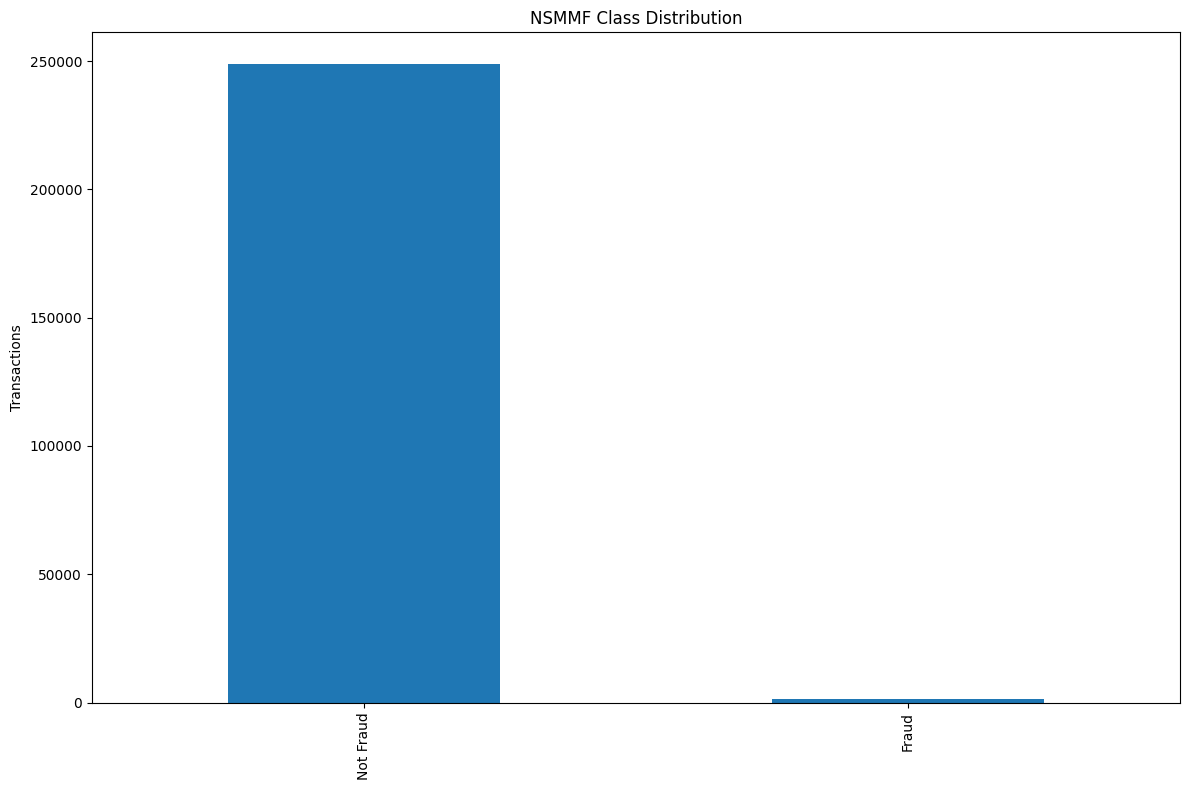

In [ ]:
plt.figure(figsize=(12, 8))
nsmmf_clean["is_fraud"].value_counts().sort_index().rename(
    index={0: "Not Fraud", 1: "Fraud"}
).plot(kind="bar")
plt.title("NSMMF Class Distribution")
plt.ylabel("Transactions")
plt.xlabel("")
plt.tight_layout()
plt.show()

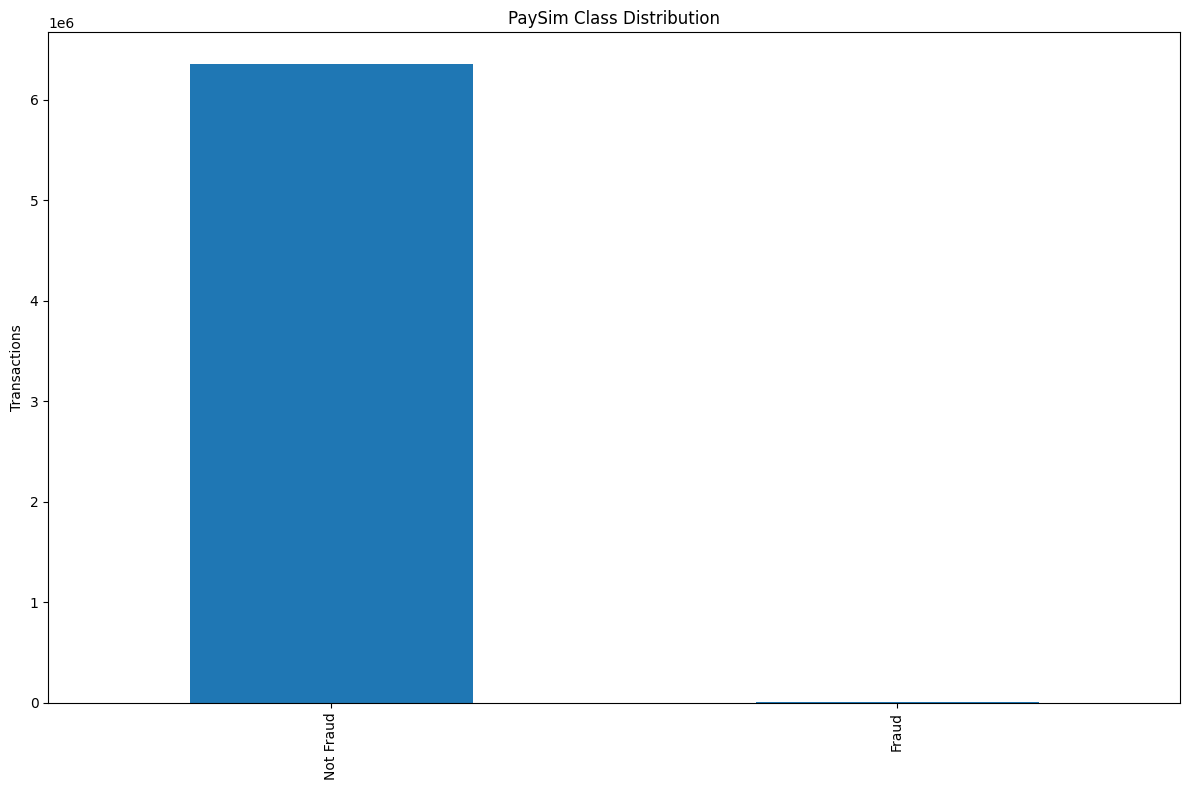

In [ ]:
plt.figure(figsize=(12, 8))
paysim_clean["isFraud"].value_counts().sort_index().rename(
    index={0: "Not Fraud", 1: "Fraud"}
).plot(kind="bar")
plt.title("PaySim Class Distribution")
plt.ylabel("Transactions")
plt.xlabel("")
plt.tight_layout()
plt.show()

Because fraud is rare in both datasets, **accuracy alone is not an appropriate primary metric**. In the modelling stage, I will prioritise Precision, Recall, F1-Score and PR-AUC.

### 7.2 Memory-conscious PaySim EDA sample

Full PaySim is retained for grouped summaries and later experiments.  
For expensive distribution plots, all fraud rows are retained while a reproducible subset of legitimate rows is sampled. This sample is **for visualisation only**, not for final evaluation.

In [ ]:
paysim_eda_legit_n = min(
    PAYSIM_EDA_LEGIT_ROWS,
    int((paysim_clean["isFraud"] == 0).sum())
)

paysim_fraud_eda = paysim_clean[paysim_clean["isFraud"] == 1]

paysim_legit_eda = (
    paysim_clean[paysim_clean["isFraud"] == 0]
    .sample(
        n=paysim_eda_legit_n,
        random_state=RANDOM_STATE
    )
)

paysim_eda = pd.concat(
    [paysim_fraud_eda, paysim_legit_eda],
    ignore_index=True
)

print("PaySim plotting sample:", paysim_eda.shape)
print(
    "Note: this sample intentionally does not preserve the natural class prevalence."
)

PaySim plotting sample: (308197, 13)
Note: this sample intentionally does not preserve the natural class prevalence.


### 7.3 Transaction amount distributions

In [ ]:
nsmmf_amount_summary = nsmmf_clean.groupby("is_fraud")["amount"].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)
nsmmf_amount_summary.index = ["Not Fraud", "Fraud"]

display(nsmmf_amount_summary.round(2))

,count,mean,std,min,50%,90%,95%,99%,max
Not Fraud,248750.0,8934.91,13598.45,74.8,5000.00,20000.0,29900.0,62528.10,572400.0
Fraud,1250.0,22526.92,38882.43,100.0,9854.67,54348.3,82325.0,177448.71,528600.0


In [ ]:
paysim_amount_summary = paysim_clean.groupby("isFraud")["amount"].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)
paysim_amount_summary.index = ["Not Fraud", "Fraud"]

display(paysim_amount_summary.round(2))

,count,mean,std,min,50%,90%,95%,99%,max
Not Fraud,6353880.0,178211.16,591539.94,0.01,74700.91,364390.68,515636.19,1586133.62,92445520.0
Fraud,8197.0,1452533.38,2378651.25,0.00,438859.09,4448599.00,7758036.50,10000000.00,10000000.0


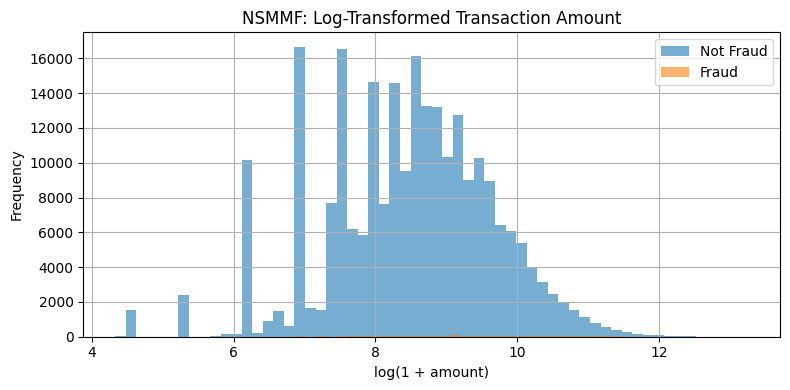

In [ ]:
plt.figure(figsize=(8, 4))
np.log1p(
    nsmmf_clean.loc[nsmmf_clean["is_fraud"] == 0, "amount"]
).hist(bins=60, alpha=0.6, label="Not Fraud")

np.log1p(
    nsmmf_clean.loc[nsmmf_clean["is_fraud"] == 1, "amount"]
).hist(bins=60, alpha=0.6, label="Fraud")

plt.title("NSMMF: Log-Transformed Transaction Amount")
plt.xlabel("log(1 + amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

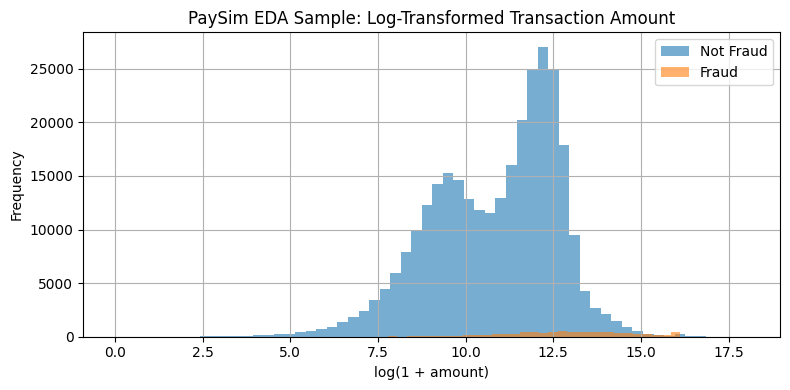

In [ ]:
plt.figure(figsize=(8, 4))
np.log1p(
    paysim_eda.loc[paysim_eda["isFraud"] == 0, "amount"]
).hist(bins=60, alpha=0.6, label="Not Fraud")

np.log1p(
    paysim_eda.loc[paysim_eda["isFraud"] == 1, "amount"]
).hist(bins=60, alpha=0.6, label="Fraud")

plt.title("PaySim EDA Sample: Log-Transformed Transaction Amount")
plt.xlabel("log(1 + amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Fraud rate by transaction type

In [ ]:
nsmmf_type_summary = nsmmf_clean.groupby("transaction_type").agg(
    transactions=("is_fraud", "size"),
    fraud_cases=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean")
).sort_values("fraud_rate", ascending=False)

nsmmf_type_summary["fraud_rate_percent"] = (
    nsmmf_type_summary["fraud_rate"] * 100
)

display(nsmmf_type_summary.round(4))

,transactions,fraud_cases,fraud_rate,fraud_rate_percent
transaction_type,,,,
P2P_TRANSFER,73342,974,0.0133,1.3280
CASH_OUT,32998,148,0.0045,0.4485
AIRTIME_PURCHASE,29434,29,0.0010,0.0985
BILL_PAYMENT,28510,28,0.0010,0.0982
CASH_IN,29316,26,0.0009,0.0887
MERCHANT_PAYMENT,56400,45,0.0008,0.0798


In [ ]:
paysim_type_summary = paysim_clean.groupby(
    "type",
    observed=True
).agg(
    transactions=("isFraud", "size"),
    fraud_cases=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean")
).sort_values("fraud_rate", ascending=False)

paysim_type_summary["fraud_rate_percent"] = (
    paysim_type_summary["fraud_rate"] * 100
)

display(paysim_type_summary.round(4))

,transactions,fraud_cases,fraud_rate,fraud_rate_percent
type,,,,
TRANSFER,532909,4097,0.0077,0.7688
CASH_OUT,2237484,4100,0.0018,0.1832
CASH_IN,1399284,0,0.0000,0.0000
DEBIT,41432,0,0.0000,0.0000
PAYMENT,2150968,0,0.0000,0.0000


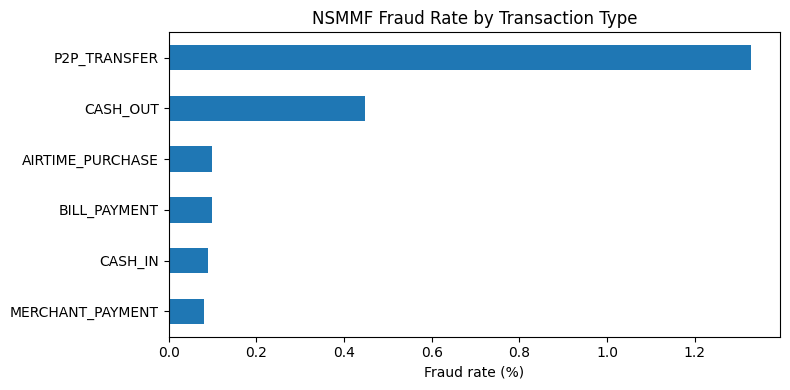

In [ ]:
plt.figure(figsize=(8, 4))
nsmmf_type_summary["fraud_rate_percent"].sort_values().plot(
    kind="barh"
)
plt.title("NSMMF Fraud Rate by Transaction Type")
plt.xlabel("Fraud rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

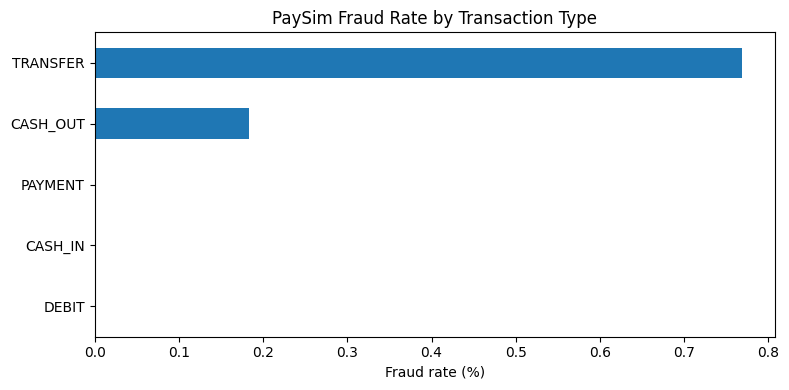

In [ ]:
plt.figure(figsize=(8, 4))
paysim_type_summary["fraud_rate_percent"].sort_values().plot(
    kind="barh"
)
plt.title("PaySim Fraud Rate by Transaction Type")
plt.xlabel("Fraud rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 7.5 Temporal patterns

NSMMF timestamps represent the synthetic transaction timestamps generated for this project. PaySim is different: `step` is a **relative simulation clock** in which one step represents one simulated hour. Therefore the derived PaySim `hour` and `day` variables describe position within the simulation cycle; they should not be interpreted as actual clock/calendar observations or compared one-for-one with real-world Nigerian hour-of-day behaviour.

In [ ]:
nsmmf_hourly = nsmmf_clean.groupby("hour").agg(
    transactions=("is_fraud", "size"),
    fraud_rate=("is_fraud", "mean")
)
nsmmf_hourly["fraud_rate_percent"] = nsmmf_hourly["fraud_rate"] * 100

display(nsmmf_hourly.round(4))

,transactions,fraud_rate,fraud_rate_percent
hour,,,
0,1304,0.0061,0.6135
1,1305,0.0077,0.7663
2,1231,0.0097,0.9748
3,1231,0.0065,0.6499
4,1211,0.0091,0.9083
5,1228,0.0065,0.6515
6,7370,0.0035,0.3528
7,7563,0.0052,0.5157
8,7529,0.0050,0.5047


In [ ]:
paysim_hourly = paysim_clean.groupby("hour").agg(
    transactions=("isFraud", "size"),
    fraud_rate=("isFraud", "mean")
)
paysim_hourly["fraud_rate_percent"] = paysim_hourly["fraud_rate"] * 100

display(paysim_hourly.round(4))

,transactions,fraud_rate,fraud_rate_percent
hour,,,
0,27111,0.0132,1.3205
1,9017,0.0411,4.1145
2,2004,0.1612,16.1178
3,1241,0.2208,22.0790
4,1641,0.2230,22.3035
5,3419,0.1044,10.4416
6,8987,0.0365,3.6497
7,26914,0.0137,1.3673
8,283509,0.0012,0.1203


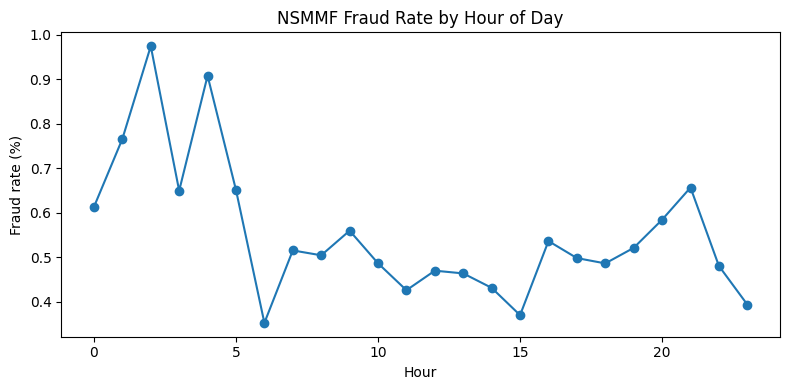

In [ ]:
plt.figure(figsize=(8, 4))
nsmmf_hourly["fraud_rate_percent"].plot(marker="o")
plt.title("NSMMF Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud rate (%)")
plt.tight_layout()
plt.show()

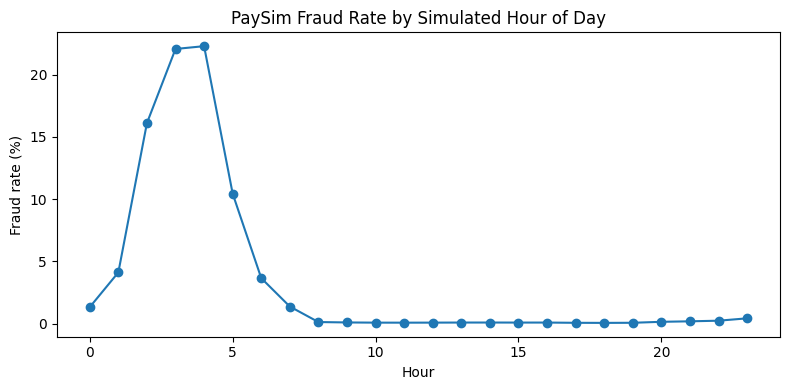

In [ ]:
plt.figure(figsize=(8, 4))
paysim_hourly["fraud_rate_percent"].plot(marker="o")
plt.title("PaySim Fraud Rate by Simulated Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud rate (%)")
plt.tight_layout()
plt.show()

### 7.6 NSMMF behavioural signals

In [ ]:
nsmmf_behaviour_features = [
    "amount_deviation_ratio",
    "transactions_last_1h",
    "transactions_last_24h",
    "is_new_device",
    "sim_changed_last_7d",
    "location_changed",
    "is_new_recipient",
    "is_unusual_hour",
    "receiver_incoming_tx_24h",
    "receiver_unique_senders_24h",
]

nsmmf_behaviour_summary = (
    nsmmf_clean
    .groupby("is_fraud")[nsmmf_behaviour_features]
    .mean()
    .T
)

nsmmf_behaviour_summary.columns = ["Not Fraud", "Fraud"]

display(nsmmf_behaviour_summary.round(4))

,Not Fraud,Fraud
amount_deviation_ratio,1.5355,4.1472
transactions_last_1h,0.0567,0.1928
transactions_last_24h,0.3221,0.4576
is_new_device,0.0401,0.3448
sim_changed_last_7d,0.0154,0.1680
location_changed,0.0017,0.1064
is_new_recipient,0.4154,0.9992
is_unusual_hour,0.1755,0.1880
receiver_incoming_tx_24h,0.0290,0.0464
receiver_unique_senders_24h,0.0266,0.0448


### 7.7a Correlation and multicollinearity check — NSMMF

Logistic Regression is included as an interpretable baseline, so strong correlations between numerical predictors should be documented. Multicollinearity does not automatically invalidate prediction, but it can make individual Logistic Regression coefficients unstable or difficult to interpret.

The heatmap provides an overview, while the table below isolates feature pairs with absolute correlation of at least **0.80**. These relationships will be considered when interpreting Logistic Regression coefficients and during later ablation/sensitivity analysis.


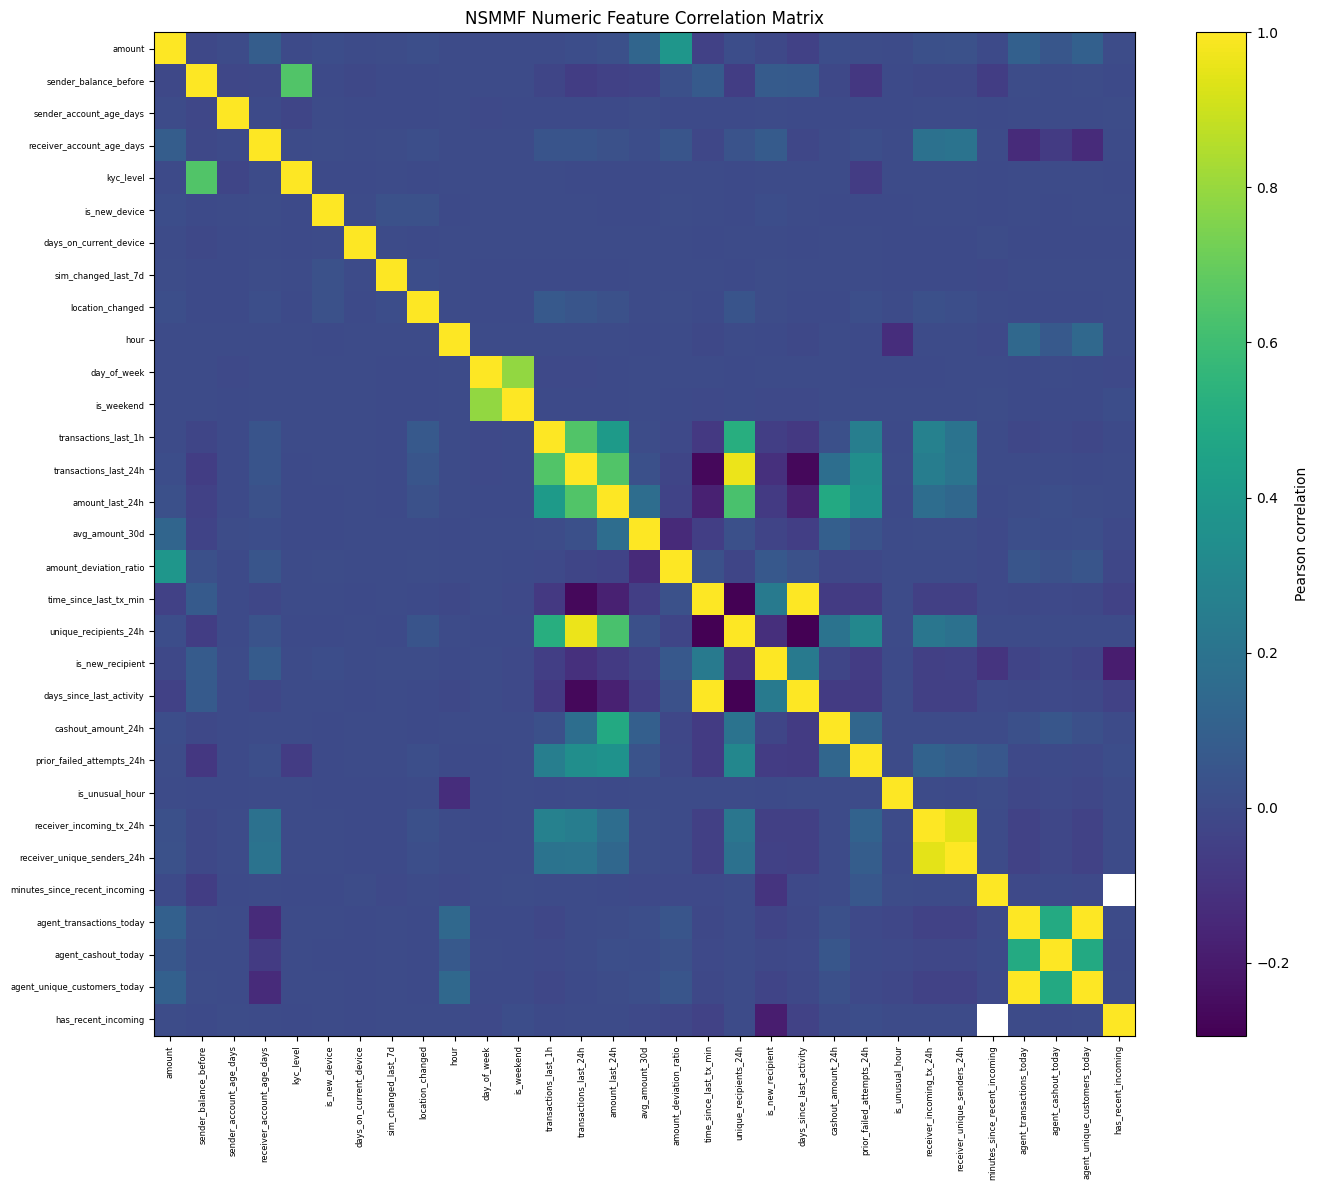

In [ ]:
nsmmf_numeric_for_corr = (
    nsmmf_clean
    .select_dtypes(include=[np.number])
    .drop(columns=["is_fraud"], errors="ignore")
)

nsmmf_corr = nsmmf_numeric_for_corr.corr()

plt.figure(figsize=(14, 12))
plt.imshow(nsmmf_corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(
    range(len(nsmmf_corr.columns)),
    nsmmf_corr.columns,
    rotation=90,
    fontsize=6
)
plt.yticks(
    range(len(nsmmf_corr.index)),
    nsmmf_corr.index,
    fontsize=6
)
plt.title("NSMMF Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
corr_abs = nsmmf_corr.abs()
upper_mask = np.triu(
    np.ones(corr_abs.shape, dtype=bool),
    k=1
)

high_corr_pairs = (
    corr_abs
    .where(upper_mask)
    .stack()
    .reset_index()
)
high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "abs_correlation"
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["abs_correlation"] >= 0.80
    ]
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

display(high_corr_pairs)


,feature_1,feature_2,abs_correlation
0,time_since_last_tx_min,days_since_last_activity,1.000000
1,agent_transactions_today,agent_unique_customers_today,0.996017
2,transactions_last_24h,unique_recipients_24h,0.964341
3,receiver_incoming_tx_24h,receiver_unique_senders_24h,0.949170


### 7.7b Correlation and multicollinearity check — PaySim

In [ ]:
# Numeric PaySim features available for correlation analysis
paysim_corr_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "hour",
    "day",
    "is_night",
    "origin_balance_error",
    "destination_balance_error",
    "isFraud"
]

paysim_corr = (
    paysim_clean[paysim_corr_features]
    .corr(numeric_only=True)
)

display(paysim_corr.round(3))

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour,day,is_night,origin_balance_error,destination_balance_error,isFraud
step,1.000,0.022,-0.010,-0.010,0.028,0.026,0.065,1.000,0.017,-0.021,0.028,0.031
amount,0.022,1.000,-0.003,-0.008,0.294,0.459,-0.037,0.023,-0.015,-0.971,-0.190,0.076
oldbalanceOrg,-0.010,-0.003,1.000,0.999,0.066,0.042,-0.005,-0.010,-0.002,-0.050,0.156,0.010
newbalanceOrig,-0.010,-0.008,0.999,1.000,0.068,0.042,-0.005,-0.010,-0.003,-0.057,0.163,-0.008
oldbalanceDest,0.028,0.294,0.066,0.068,1.000,0.977,-0.006,0.028,-0.012,-0.304,-0.025,-0.006
newbalanceDest,0.026,0.459,0.042,0.042,0.977,1.000,-0.012,0.026,-0.014,-0.459,-0.175,0.000
hour,0.065,-0.037,-0.005,-0.005,-0.006,-0.012,1.000,0.036,0.202,0.037,0.004,-0.028
day,1.000,0.023,-0.010,-0.010,0.028,0.026,0.036,1.000,0.011,-0.022,0.028,0.032
is_night,0.017,-0.015,-0.002,-0.003,-0.012,-0.014,0.202,0.011,1.000,0.021,0.004,0.052
origin_balance_error,-0.021,-0.971,-0.050,-0.057,-0.304,-0.459,0.037,-0.022,0.021,1.000,0.148,0.011


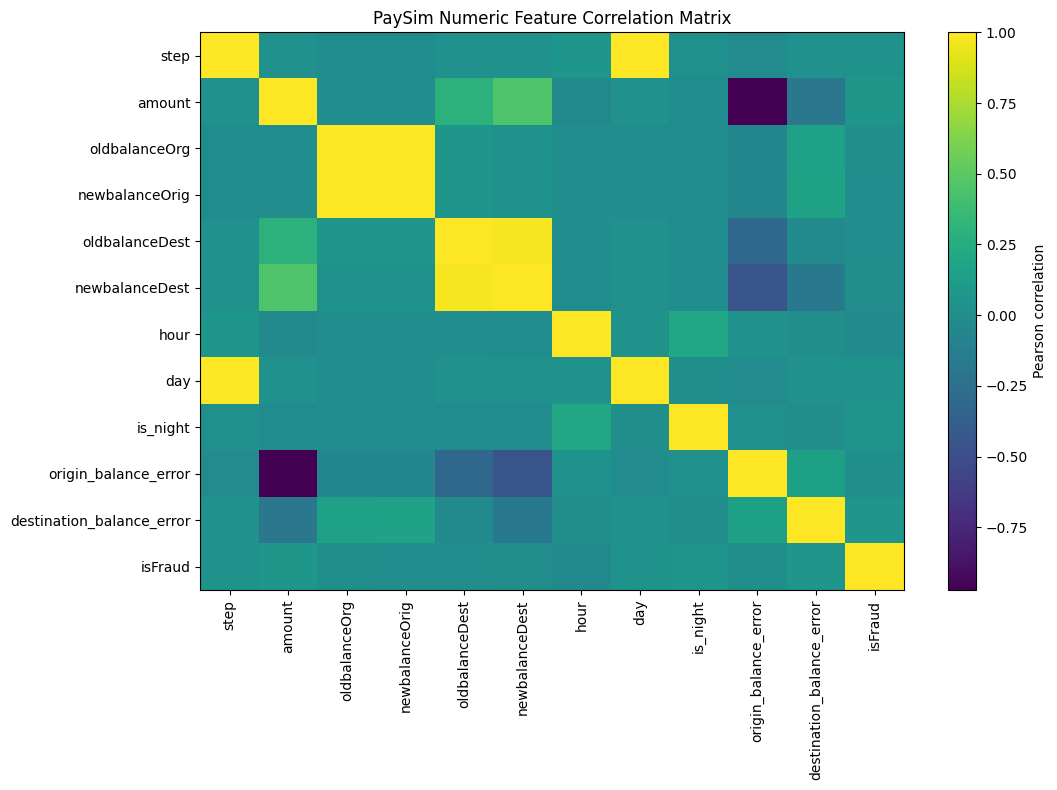

In [ ]:
plt.figure(figsize=(11, 8))

plt.imshow(
    paysim_corr,
    aspect="auto"
)

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(paysim_corr.columns)),
    paysim_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(paysim_corr.index)),
    paysim_corr.index
)

plt.title("PaySim Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Find highly correlated feature pairs
corr_abs = paysim_corr.abs()

upper_triangle = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "abs_correlation"
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["abs_correlation"] >= 0.80
    ]
    .sort_values(
        "abs_correlation",
        ascending=False
    )
)

display(high_corr_pairs)

,feature_1,feature_2,abs_correlation
6,step,day,0.999586
21,oldbalanceOrg,newbalanceOrig,0.998817
38,oldbalanceDest,newbalanceDest,0.976577
18,amount,origin_balance_error,0.970975


In [ ]:
paysim_predictor_corr_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "hour",
    "day",
    "is_night",
    "origin_balance_error",
    "destination_balance_error",
]

predictor_corr = (
    paysim_clean[paysim_predictor_corr_features]
    .corr()
)

In [ ]:
PAYSIM_CORE_FEATURES = [
    "amount",
    "hour",
    "day",
    "is_night"
]

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

paysim_vif_data = (
    paysim_clean[
        ["amount", "hour", "day", "is_night"]
    ]
    .dropna()
    .astype(float)
)

# Sampling keeps the calculation lightweight
vif_sample = paysim_vif_data.sample(
    n=min(PAYSIM_VIF_SAMPLE_SIZE, len(paysim_vif_data)),
    random_state=RANDOM_STATE
)

paysim_vif = pd.DataFrame({
    "feature": vif_sample.columns,
    "VIF": [
        variance_inflation_factor(
            vif_sample.values,
            i
        )
        for i in range(vif_sample.shape[1])
    ]
})

display(paysim_vif.round(3))

,feature,VIF
0,amount,1.097
1,hour,3.600
2,day,3.477
3,is_night,1.070


>**Interpretation:** Correlation analysis is used to identify redundant numerical predictors before modelling. Particular care is required for `PaySim` because several variables are mathematically related. The `day`, `hour`, and `is_night` features are derived from the simulation step, while the balance-error variables are constructed directly from the original balance fields and transaction amount. Strong correlations involving these variables therefore do not necessarily indicate independent behavioural relationships.

>In addition, PaySim's documentation warns that detected fraudulent transactions are cancelled, affecting the before/after balance fields. These variables are therefore retained for exploratory and sensitivity analysis but excluded from the primary fraud-classification feature set.

### 7.8 Categorical cardinality check — NSMMF

Before one-hot encoding, the number of distinct levels in each categorical feature is inspected. This catches unexpectedly high-cardinality fields and provides an estimate of the number of dummy columns that one-hot encoding may create.

State fields are expected to have up to 37 levels (36 states plus the FCT). Raw wallet, transaction, merchant and agent identifiers are intentionally absent from the ML feature set.


In [ ]:
nsmmf_categorical_eda = (
    nsmmf_clean
    .drop(columns=["is_fraud", "timestamp"], errors="ignore")
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

categorical_cardinality = pd.DataFrame({
    "feature": nsmmf_categorical_eda,
    "unique_levels": [
        nsmmf_clean[col].nunique(dropna=False)
        for col in nsmmf_categorical_eda
    ]
}).sort_values("unique_levels", ascending=False)

categorical_cardinality["share_of_rows_percent"] = (
    categorical_cardinality["unique_levels"] /
    len(nsmmf_clean) * 100
)

display(categorical_cardinality)

estimated_one_hot_columns = int(
    categorical_cardinality["unique_levels"].sum()
)

print(
    "Approximate categorical one-hot width (before any dropped levels):",
    estimated_one_hot_columns
)


,feature,unique_levels,share_of_rows_percent
3,receiver_state,37,0.0148
2,sender_state,37,0.0148
4,transaction_state,37,0.0148
0,transaction_type,6,0.0024
5,geo_zone,6,0.0024
1,initiation_channel,3,0.0012
6,urban_rural,3,0.0012
7,device_type,2,0.0008


Approximate categorical one-hot width (before any dropped levels): 131


### 7.9 NSMMF fraud scenarios — audit only

In [ ]:
scenario_counts = (
    nsmmf_full.loc[
        nsmmf_full["is_fraud"] == 1,
        "fraud_type"
    ]
    .value_counts()
    .rename("transactions")
)

display(scenario_counts.to_frame())

,transactions
fraud_type,
social_engineering,328
account_takeover,226
mule_activity,194
sim_device_compromise,177
rapid_cashout,121
velocity_fraud,106
dormant_wallet_takeover,98


In [ ]:
scenario_behaviour = (
    nsmmf_full.loc[nsmmf_full["is_fraud"] == 1]
    .groupby("fraud_type")
    .agg(
        transactions=("is_fraud", "size"),
        mean_amount=("amount", "mean"),
        new_device_rate=("is_new_device", "mean"),
        sim_change_rate=("sim_changed_last_7d", "mean"),
        location_change_rate=("location_changed", "mean"),
        new_recipient_rate=("is_new_recipient", "mean"),
        unusual_hour_rate=("is_unusual_hour", "mean"),
        mean_tx_last_1h=("transactions_last_1h", "mean"),
        mean_amount_deviation=("amount_deviation_ratio", "mean"),
    )
)

display(scenario_behaviour.round(3))

,transactions,mean_amount,new_device_rate,sim_change_rate,location_change_rate,new_recipient_rate,unusual_hour_rate,mean_tx_last_1h,mean_amount_deviation
fraud_type,,,,,,,,,
account_takeover,226,30462.253,0.712,0.199,0.412,1.000,0.155,0.027,4.525
dormant_wallet_takeover,98,43202.018,0.796,0.000,0.000,1.000,0.194,0.000,12.194
mule_activity,194,21771.830,0.021,0.015,0.057,1.000,0.170,0.026,3.860
rapid_cashout,121,23495.912,0.050,0.017,0.058,1.000,0.190,0.017,5.924
sim_device_compromise,177,19880.411,0.881,0.870,0.045,1.000,0.181,0.028,2.790
social_engineering,328,16875.220,0.073,0.012,0.043,1.000,0.223,0.024,2.722
velocity_fraud,106,8676.774,0.019,0.019,0.000,0.991,0.189,2.028,1.075


---
## 8 — Leakage and Synthetic-Shortcut Audit

### NSMMF

The ML file already excludes obvious audit-only fields such as transaction IDs, wallet IDs, `fraud_type`, `fraud_event_id`, hidden customer profiles, transaction status, and post-transaction balances.

However, some model-safe variables may still be **synthetically over-predictive** because of the way fraud scenarios were generated. In particular:

- `is_new_recipient`
- `location_changed`

These will be tested through later ablation experiments.

### PaySim

The PaySim documentation states that fraud-detected transactions are cancelled, which affects the balance fields. Therefore:

- the **primary PaySim model excludes all four balance columns**;
- the balance-error variables are excluded from the primary model;
- balance-based variables may be explored only in a clearly labelled sensitivity/ablation experiment.

This prevents a benchmark score from being driven primarily by simulation mechanics.

### How EDA question 4 is handled for PaySim

For PaySim, synthetic over-predictiveness is assessed in two stages. The core inputs `type` and `amount` are inspected directly by fraud class during EDA, while the balance variables and engineered balance-error variables are kept outside the primary model and reserved for a later sensitivity experiment. This explicitly separates ordinary transaction signal from simulator-specific balance mechanics.

In [ ]:
nsmmf_audit_features = [
    "amount",
    "amount_deviation_ratio",
    "transactions_last_1h",
    "transactions_last_24h",
    "is_new_device",
    "sim_changed_last_7d",
    "location_changed",
    "is_new_recipient",
    "is_unusual_hour",
    "receiver_incoming_tx_24h",
    "receiver_unique_senders_24h",
    "days_since_last_activity",
]

nsmmf_feature_means = (
    nsmmf_clean
    .groupby("is_fraud")[nsmmf_audit_features]
    .mean()
    .T
)

nsmmf_feature_means.columns = [
    "legitimate_mean",
    "fraud_mean"
]

nsmmf_feature_means["fraud_to_legitimate_ratio"] = (
    nsmmf_feature_means["fraud_mean"] /
    nsmmf_feature_means["legitimate_mean"].replace(0, np.nan)
)

display(nsmmf_feature_means.round(4))

,legitimate_mean,fraud_mean,fraud_to_legitimate_ratio
amount,8934.9110,22526.9199,2.5212
amount_deviation_ratio,1.5355,4.1472,2.7009
transactions_last_1h,0.0567,0.1928,3.4006
transactions_last_24h,0.3221,0.4576,1.4206
is_new_device,0.0401,0.3448,8.6062
sim_changed_last_7d,0.0154,0.1680,10.9255
location_changed,0.0017,0.1064,64.2403
is_new_recipient,0.4154,0.9992,2.4056
is_unusual_hour,0.1755,0.1880,1.0713
receiver_incoming_tx_24h,0.0290,0.0464,1.5986


In [ ]:
paysim_core_audit = pd.DataFrame({
    "Not Fraud": [
        paysim_clean.loc[
            paysim_clean["isFraud"] == 0,
            "amount"
        ].mean(),
        paysim_clean.loc[
            paysim_clean["isFraud"] == 0,
            "amount"
        ].median(),
    ],
    "Fraud": [
        paysim_clean.loc[
            paysim_clean["isFraud"] == 1,
            "amount"
        ].mean(),
        paysim_clean.loc[
            paysim_clean["isFraud"] == 1,
            "amount"
        ].median(),
    ],
}, index=["Mean amount", "Median amount"])

display(paysim_core_audit.round(2))
display(
    paysim_type_summary[
        ["transactions", "fraud_cases", "fraud_rate_percent"]
    ].round(4)
)


,Not Fraud,Fraud
Mean amount,178211.16,1452533.38
Median amount,74700.91,438859.09


,transactions,fraud_cases,fraud_rate_percent
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237484,4100,0.1832
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2150968,0,0.0000


In [ ]:
paysim_balance_audit = (
    paysim_clean
    .groupby("isFraud")[
        [
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "origin_balance_error",
            "destination_balance_error",
        ]
    ]
    .mean()
    .T
)

paysim_balance_audit.columns = ["Not Fraud", "Fraud"]

display(paysim_balance_audit.round(2))

,Not Fraud,Fraud
oldbalanceOrg,8.328978e+05,1.634588e+06
newbalanceOrig,8.560412e+05,1.927682e+05
oldbalanceDest,1.101512e+06,5.453120e+05
newbalanceDest,1.225027e+06,1.263906e+06
origin_balance_error,-2.013547e+05,-1.071320e+04
destination_balance_error,5.469616e+04,7.339391e+05


---
## 9 — Preprocessing

Preprocessing is defined here, but **all learned preprocessing parameters must be fitted on training data only**. Concretely:

- imputers learn medians/modes from `nsmmf_train` or `paysim_train` only;
- scalers learn means/standard deviations from training data only;
- one-hot encoders learn category vocabularies from training data only;
- validation and test data are transformed using those already-fitted objects;
- no resampling or target-informed transformation is fitted on validation/test data.

The pipelines below are the primary preprocessing definitions for the **Logistic Regression baseline**. Tree-based models do not require numerical scaling, so the modelling section may clone/adapt these pipelines while preserving the same train-only fitting rule.

Two separate preprocessing pipelines are required because NSMMF and PaySim have different schemas. A train-only fitting sanity check is performed after the chronological splits are created.

### 9.1 NSMMF feature sets

In [ ]:
NSMMF_TARGET = "is_fraud"
NSMMF_SPLIT_COL = "timestamp"

# Full model-safe predictor set.
nsmmf_predictor_cols = [
    c for c in nsmmf_clean.columns
    if c not in [NSMMF_TARGET, NSMMF_SPLIT_COL]
]

nsmmf_X_schema = nsmmf_clean[nsmmf_predictor_cols]

nsmmf_categorical_features = (
    nsmmf_X_schema
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

nsmmf_numeric_features = (
    nsmmf_X_schema
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

print("NSMMF categorical features:", len(nsmmf_categorical_features))
print(nsmmf_categorical_features)

print("\nNSMMF numeric features:", len(nsmmf_numeric_features))
print(nsmmf_numeric_features)

NSMMF categorical features: 8
['transaction_type', 'initiation_channel', 'sender_state', 'receiver_state', 'transaction_state', 'geo_zone', 'urban_rural', 'device_type']

NSMMF numeric features: 31
['amount', 'sender_balance_before', 'sender_account_age_days', 'receiver_account_age_days', 'kyc_level', 'is_new_device', 'days_on_current_device', 'sim_changed_last_7d', 'location_changed', 'hour', 'day_of_week', 'is_weekend', 'transactions_last_1h', 'transactions_last_24h', 'amount_last_24h', 'avg_amount_30d', 'amount_deviation_ratio', 'time_since_last_tx_min', 'unique_recipients_24h', 'is_new_recipient', 'days_since_last_activity', 'cashout_amount_24h', 'prior_failed_attempts_24h', 'is_unusual_hour', 'receiver_incoming_tx_24h', 'receiver_unique_senders_24h', 'minutes_since_recent_incoming', 'agent_transactions_today', 'agent_cashout_today', 'agent_unique_customers_today', 'has_recent_incoming']


In [ ]:
nsmmf_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

nsmmf_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

nsmmf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            nsmmf_numeric_pipeline,
            nsmmf_numeric_features
        ),
        (
            "cat",
            nsmmf_categorical_pipeline,
            nsmmf_categorical_features
        ),
    ],
    remainder="drop",
)

nsmmf_preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['amount', 'sender_balance_before',
                                  'sender_account_age_days',
                                  'receiver_account_age_days', 'kyc_level',
                                  'is_new_device', 'days_on_current_device',
                                  'sim_changed_last_7d', 'location_changed',
                                  'hour', 'day_of_week', 'is_weekend',
                                  'tra...
                                  'minutes_since_recent_incoming',
                                  'agent_transactions_today',
                                  'agent_cashout_today',
                                  'agent_unique_customers_today', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['transaction_type', 'initiation_channel',
                                  'sender_state', 'receiver_state',
                                  'transaction_state', 'geo_zone',
                                  'urban_rural', 'device_type'])])

### 9.2 NSMMF ablation feature sets

These are defined now so that the later modelling section can run consistent experiments.


In [ ]:
NSMMF_ABLATION_SETS = {
    "all_features": nsmmf_predictor_cols,

    "without_new_recipient": [
        c for c in nsmmf_predictor_cols
        if c != "is_new_recipient"
    ],

    "without_location_changed": [
        c for c in nsmmf_predictor_cols
        if c != "location_changed"
    ],

    "without_both_shortcuts": [
        c for c in nsmmf_predictor_cols
        if c not in {
            "is_new_recipient",
            "location_changed"
        }
    ],
}

for name, cols in NSMMF_ABLATION_SETS.items():
    print(name, "->", len(cols), "features")

all_features -> 39 features
without_new_recipient -> 38 features
without_location_changed -> 38 features
without_both_shortcuts -> 37 features


Results from this ablation are reported in Section 12.6 and discussed in Section 13

### 9.3 PaySim primary and sensitivity feature sets

In [ ]:
PAYSIM_TARGET = "isFraud"
PAYSIM_SPLIT_COL = "step"

# Primary PaySim predictors:
# balance variables are deliberately excluded.
PAYSIM_CORE_FEATURES = [
    "type",
    "amount",
    "hour",
    "day",
    "is_night",
]

# Sensitivity-only variables.
PAYSIM_BALANCE_FEATURES = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_error",
    "destination_balance_error",
]

PAYSIM_SENSITIVITY_FEATURES = (
    PAYSIM_CORE_FEATURES + PAYSIM_BALANCE_FEATURES
)

print("Primary PaySim features:", PAYSIM_CORE_FEATURES)
print("Sensitivity feature count:", len(PAYSIM_SENSITIVITY_FEATURES))

Primary PaySim features: ['type', 'amount', 'hour', 'day', 'is_night']
Sensitivity feature count: 11


In [ ]:
paysim_categorical_features = ["type"]

paysim_numeric_features = [
    "amount",
    "hour",
    "day",
    "is_night",
]

paysim_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

paysim_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

paysim_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            paysim_numeric_pipeline,
            paysim_numeric_features
        ),
        (
            "cat",
            paysim_categorical_pipeline,
            paysim_categorical_features
        ),
    ],
    remainder="drop",
)

paysim_preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['amount', 'hour', 'day', 'is_night']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type'])])

---
## 10 — Train / Validation / Test Splits

The validation set will be used later for:

- model selection;
- threshold selection;
- feature-ablation decisions; and
- hybrid-score tuning.

The test set should remain untouched until the final model configuration has been chosen.

### 10.1 NSMMF chronological split

In [ ]:
nsmmf_clean = (
    nsmmf_clean
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Timestamp quantiles are more robust than relying on a hard-coded
# row label for the boundary. Repeated timestamps stay in one split.
train_cut_time = nsmmf_clean["timestamp"].quantile(0.70)
valid_cut_time = nsmmf_clean["timestamp"].quantile(0.85)

nsmmf_train = nsmmf_clean[
    nsmmf_clean["timestamp"] <= train_cut_time
].copy()

nsmmf_valid = nsmmf_clean[
    (nsmmf_clean["timestamp"] > train_cut_time) &
    (nsmmf_clean["timestamp"] <= valid_cut_time)
].copy()

nsmmf_test = nsmmf_clean[
    nsmmf_clean["timestamp"] > valid_cut_time
].copy()

nsmmf_split_summary = pd.DataFrame({
    "rows": [
        len(nsmmf_train),
        len(nsmmf_valid),
        len(nsmmf_test)
    ],
    "fraud_cases": [
        nsmmf_train["is_fraud"].sum(),
        nsmmf_valid["is_fraud"].sum(),
        nsmmf_test["is_fraud"].sum()
    ],
    "fraud_rate": [
        nsmmf_train["is_fraud"].mean(),
        nsmmf_valid["is_fraud"].mean(),
        nsmmf_test["is_fraud"].mean()
    ],
    "start": [
        nsmmf_train["timestamp"].min(),
        nsmmf_valid["timestamp"].min(),
        nsmmf_test["timestamp"].min()
    ],
    "end": [
        nsmmf_train["timestamp"].max(),
        nsmmf_valid["timestamp"].max(),
        nsmmf_test["timestamp"].max()
    ],
}, index=["Train", "Validation", "Test"])

display(nsmmf_split_summary)

,rows,fraud_cases,fraud_rate,start,end
Train,175000,893,0.005103,2025-01-01 00:01:09,2025-03-05 06:08:31
Validation,37500,191,0.005093,2025-03-05 06:08:58,2025-03-18 15:09:56
Test,37500,166,0.004427,2025-03-18 15:10:04,2025-03-31 23:59:57


### 10.2 PaySim chronological split by non-overlapping `step`

In [ ]:
unique_steps = np.sort(
    paysim_clean["step"].unique()
)

n_steps = len(unique_steps)

train_step_end_idx = int(n_steps * 0.70)
valid_step_end_idx = int(n_steps * 0.85)

train_steps = unique_steps[:train_step_end_idx]
valid_steps = unique_steps[
    train_step_end_idx:valid_step_end_idx
]
test_steps = unique_steps[valid_step_end_idx:]

paysim_train = paysim_clean[
    paysim_clean["step"].isin(train_steps)
].copy()

paysim_valid = paysim_clean[
    paysim_clean["step"].isin(valid_steps)
].copy()

paysim_test = paysim_clean[
    paysim_clean["step"].isin(test_steps)
].copy()

# Confirm that no simulated hour is shared across splits.
assert set(train_steps).isdisjoint(valid_steps)
assert set(train_steps).isdisjoint(test_steps)
assert set(valid_steps).isdisjoint(test_steps)

paysim_split_summary = pd.DataFrame({
    "rows": [
        len(paysim_train),
        len(paysim_valid),
        len(paysim_test)
    ],
    "fraud_cases": [
        paysim_train["isFraud"].sum(),
        paysim_valid["isFraud"].sum(),
        paysim_test["isFraud"].sum()
    ],
    "fraud_rate": [
        paysim_train["isFraud"].mean(),
        paysim_valid["isFraud"].mean(),
        paysim_test["isFraud"].mean()
    ],
    "step_start": [
        paysim_train["step"].min(),
        paysim_valid["step"].min(),
        paysim_test["step"].min()
    ],
    "step_end": [
        paysim_train["step"].max(),
        paysim_valid["step"].max(),
        paysim_test["step"].max()
    ],
}, index=["Train", "Validation", "Test"])

display(paysim_split_summary)

,rows,fraud_cases,fraud_rate,step_start,step_end
Train,6081477,5775,0.000950,1,520
Validation,191140,1176,0.006153,521,631
Test,89460,1246,0.013928,632,743


### 10.3 Split integrity checks

In [ ]:
assert nsmmf_train["timestamp"].max() < nsmmf_valid["timestamp"].min()
assert nsmmf_valid["timestamp"].max() < nsmmf_test["timestamp"].min()

assert paysim_train["step"].max() < paysim_valid["step"].min()
assert paysim_valid["step"].max() < paysim_test["step"].min()

print("Chronological split integrity checks passed for both datasets.")

Chronological split integrity checks passed for both datasets.


### 10.4 Why chronological splitting is preferred

A random split can preserve class proportions, but it mixes early and late transactions across training, validation, and test sets. That is inappropriate for the primary experiment because fraud detection is a forward-looking task: a model should be evaluated on transactions that occur **after** the training period.

The diagnostic below uses a bounded sample only to demonstrate the temporal overlap created by random splitting. It is **not used for model fitting or final evaluation**.


In [ ]:
def random_split_temporal_diagnostic(
    df,
    target_col,
    time_col,
    max_rows=DIAGNOSTIC_SAMPLE_SIZE,
    random_state=RANDOM_STATE
):
    if len(df) > max_rows:
        diagnostic_df = df.sample(
            n=max_rows,
            random_state=random_state
        ).copy()
    else:
        diagnostic_df = df.copy()

    train_tmp, holdout_tmp = train_test_split(
        diagnostic_df,
        test_size=0.30,
        random_state=random_state,
        stratify=diagnostic_df[target_col]
    )

    valid_tmp, test_tmp = train_test_split(
        holdout_tmp,
        test_size=0.50,
        random_state=random_state,
        stratify=holdout_tmp[target_col]
    )

    return pd.DataFrame({
        "rows": [len(train_tmp), len(valid_tmp), len(test_tmp)],
        "fraud_rate": [
            train_tmp[target_col].mean(),
            valid_tmp[target_col].mean(),
            test_tmp[target_col].mean()
        ],
        "time_min": [
            train_tmp[time_col].min(),
            valid_tmp[time_col].min(),
            test_tmp[time_col].min()
        ],
        "time_max": [
            train_tmp[time_col].max(),
            valid_tmp[time_col].max(),
            test_tmp[time_col].max()
        ],
    }, index=["Random Train", "Random Validation", "Random Test"])

print("NSMMF random-split diagnostic")
display(
    random_split_temporal_diagnostic(
        nsmmf_clean,
        target_col="is_fraud",
        time_col="timestamp"
    )
)

print("PaySim random-split diagnostic (bounded sample)")
display(
    random_split_temporal_diagnostic(
        paysim_clean,
        target_col="isFraud",
        time_col="step"
    )
)


NSMMF random-split diagnostic


,rows,fraud_rate,time_min,time_max
Random Train,140000,0.005021,2025-01-01 00:01:09,2025-03-31 23:59:33
Random Validation,30000,0.005033,2025-01-01 01:29:13,2025-03-31 23:58:51
Random Test,30000,0.005000,2025-01-01 00:13:39,2025-03-31 23:59:57


PaySim random-split diagnostic (bounded sample)


,rows,fraud_rate,time_min,time_max
Random Train,140000,0.001379,1,736
Random Validation,30000,0.001367,1,738
Random Test,30000,0.001367,1,724


The random-split tables should show overlapping temporal ranges across all three partitions, whereas the chronological split has non-overlapping periods by construction. This is why the chronological partitions—not the random diagnostic—are used for the modelling results.


### 10.5 Train-only preprocessing fit and output dimensionality check

Before modelling, the baseline preprocessors are fitted **only on the training partitions** to verify that encoding/scaling succeeds and to measure transformed feature dimensionality. Validation and test sets are not used in this fitting step.

This check is especially useful for confirming that one-hot encoding has not created an unexpectedly large feature space.


In [ ]:
# Clone so the definitions above remain reusable in the modelling section.
nsmmf_preprocessor_check = clone(nsmmf_preprocessor)
paysim_preprocessor_check = clone(paysim_preprocessor)

nsmmf_preprocessor_check.fit(
    nsmmf_train[nsmmf_predictor_cols]
)

paysim_preprocessor_check.fit(
    paysim_train[PAYSIM_CORE_FEATURES]
)

nsmmf_transformed_features = (
    nsmmf_preprocessor_check.get_feature_names_out()
)
paysim_transformed_features = (
    paysim_preprocessor_check.get_feature_names_out()
)

preprocessing_shape_summary = pd.DataFrame({
    "training_rows": [
        len(nsmmf_train),
        len(paysim_train)
    ],
    "raw_predictor_columns": [
        len(nsmmf_predictor_cols),
        len(PAYSIM_CORE_FEATURES)
    ],
    "transformed_feature_columns": [
        len(nsmmf_transformed_features),
        len(paysim_transformed_features)
    ],
}, index=["NSMMF", "PaySim"])

display(preprocessing_shape_summary)

print("First NSMMF transformed features:")
print(nsmmf_transformed_features[:20])

print("\nPaySim transformed features:")
print(paysim_transformed_features)

,training_rows,raw_predictor_columns,transformed_feature_columns
NSMMF,175000,39,162
PaySim,6081477,5,9


First NSMMF transformed features:
['num__amount' 'num__sender_balance_before' 'num__sender_account_age_days'
 'num__receiver_account_age_days' 'num__kyc_level' 'num__is_new_device'
 'num__days_on_current_device' 'num__sim_changed_last_7d'
 'num__location_changed' 'num__hour' 'num__day_of_week' 'num__is_weekend'
 'num__transactions_last_1h' 'num__transactions_last_24h'
 'num__amount_last_24h' 'num__avg_amount_30d'
 'num__amount_deviation_ratio' 'num__time_since_last_tx_min'
 'num__unique_recipients_24h' 'num__is_new_recipient']

PaySim transformed features:
['num__amount' 'num__hour' 'num__day' 'num__is_night' 'cat__type_CASH_IN'
 'cat__type_CASH_OUT' 'cat__type_DEBIT' 'cat__type_PAYMENT'
 'cat__type_TRANSFER']


---
## 11 — Pre-Modelling Conclusions and Experimental Plan

At this point both datasets have followed a logically comparable preparation path:

**Acquisition → Loading → Validation → Cleaning → Feature Engineering → EDA → Correlation/Cardinality Checks → Leakage Audit → Preprocessing Definition → Chronological Splitting → Train-Only Preprocessor Sanity Check**

Key implications for modelling:

1. **Class imbalance is substantial**, so accuracy will be reported but not treated as the primary success metric.
2. **NSMMF contains behavioural features** that make it suitable for supervised and anomaly-based fraud analysis.
3. `is_new_recipient` and `location_changed` may be unusually strong NSMMF synthetic signals and will be tested through ablation.
4. Strong NSMMF numeric correlations are documented before Logistic Regression so coefficient interpretation can account for multicollinearity.
5. NSMMF categorical cardinality is checked before one-hot encoding; raw account/entity identifiers remain excluded from the ML feature set.
6. **PaySim balance variables are excluded from the primary benchmark model** because the dataset documentation warns that cancelled fraud transactions affect these fields.
7. `isFlaggedFraud` is excluded because it is an existing rule/simulator flag, while `nameOrig` and `nameDest` are excluded as raw high-cardinality identifiers.
8. PaySim balance variables can still be used in a clearly labelled **sensitivity experiment**, not as the main benchmark.
9. PaySim `hour` and `day` features are derived from a **simulation clock**, not observed real-world calendar timestamps.
10. Both datasets use **chronological train/validation/test partitions**; a random-split diagnostic is included only to demonstrate why temporal separation is preferred.
11. Baseline preprocessing is fitted only on training data, and transformed feature dimensionality is checked before modelling.
12. Validation data—not test data—will be used for threshold optimisation and hybrid-score tuning.
13. PaySim and NSMMF will be modelled **separately**. Their rows will not be concatenated.

---
## 12 — Machine Learning Modelling

This section builds the fraud-detection models using the train/validation/test partitions created in the pre-modelling stage.

The modelling protocol is deliberately strict:

- models and preprocessing objects are fitted on the **training set only**;
- model choice, threshold selection, feature-ablation decisions, anomaly thresholds, and hybrid-score weights use the **validation set only**;
- the chronological **test set remains untouched** until the final evaluation;
- PaySim and NSMMF are modelled separately;
- **PR-AUC, Precision, Recall, and F1-Score** receive more emphasis than Accuracy because fraud is rare;
- Random Forest is used as the stronger supervised model because it is available directly in scikit-learn and avoids introducing an additional XGBoost dependency.

The probabilities returned by class-weighted classifiers are treated as model fraud scores/estimated probabilities. They are useful for ranking and threshold analysis, but they should not be interpreted as perfectly calibrated real-world fraud probabilities without a separate calibration study.

### 12.1 Evaluation framework and reusable metric functions

A reusable evaluation layer is created first so that every supervised, anomaly, ablation, and hybrid experiment is assessed consistently.

The reported metrics are:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC
- Average Precision
- confusion-matrix counts: TN, FP, FN, TP

Because fraud is a highly imbalanced classification problem, no single metric is sufficient to evaluate model performance.

* **Accuracy** measures the overall proportion of correct predictions, but can be misleading when fraud is rare because a model may achieve high Accuracy by predicting most transactions as legitimate.
* **Balanced Accuracy** averages Recall across the fraud and legitimate classes, giving both classes equal importance regardless of their frequency. It is more informative than ordinary Accuracy under class imbalance, but it still does not show whether errors are mainly false positives or false negatives.
* **Precision** measures how many transactions flagged as fraud are actually fraudulent. Higher Precision reduces false alerts, but may come at the cost of missing more fraud cases.
* **Recall** measures how much of the actual fraud is detected. It is particularly important in fraud detection because low Recall means many fraudulent transactions are missed; however, increasing Recall can substantially increase false positives.
* **F1-score** balances Precision and Recall at a specific classification threshold. It is useful for comparing operating points, but assumes Precision and Recall are equally important and does not incorporate the potentially different financial costs of false positives and false negatives.
* **ROC-AUC** measures ranking performance across thresholds, but can appear optimistic under severe class imbalance because the large number of legitimate transactions strongly influences the false-positive rate.
* **PR-AUC and Average Precision** summarise performance on the Precision–Recall relationship and are especially useful when the positive fraud class is rare. They emphasise the model's ability to identify fraud without generating excessive false positives. However, both are influenced by fraud prevalence, so values across datasets or time periods with different class distributions should be compared cautiously. PR-AUC is used as the primary ranking criterion in this project.
* **Confusion-matrix counts** provide the operational context behind the summary metrics by showing the actual numbers of false positives and false negatives.

Threshold selection therefore represents an operational trade-off rather than a universally optimal decision. The max-F1 thresholds used in this study are experimental operating points and should not be interpreted as production-optimal thresholds without transaction-cost, customer-impact and fraud-loss analysis.

For this imbalanced fraud-detection problem, **PR-AUC** is prioritised for model ranking, while **Recall and Precision** are used to assess the operational consequences of the selected threshold. **Accuracy** is reported for completeness but is not used as the primary measure of model quality.

In [ ]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# MODEL TRAINING RESOURCE SETTINGS
# Change ONLY this cell when running sensitivity experiments.
# ============================================================

# Supervised models
PAYSIM_LR_TRAIN_CAP = None         # Use full PaySim training partition
PAYSIM_RF_TRAIN_CAP = 1_500_000    # Final selected RF training cap

# Isolation Forest: legitimate training rows only
NSMMF_IF_NORMAL_CAP = 150_000
PAYSIM_IF_NORMAL_CAP = 500_000     # Final legitimate reference-pool cap

print("Model training resource settings")
print("--------------------------------")
print("PaySim LR cap:", PAYSIM_LR_TRAIN_CAP)
print("PaySim RF cap:", f"{PAYSIM_RF_TRAIN_CAP:,}")
print("NSMMF IF legitimate cap:", f"{NSMMF_IF_NORMAL_CAP:,}")
print("PaySim IF legitimate cap:", f"{PAYSIM_IF_NORMAL_CAP:,}")

Model training resource settings
--------------------------------
PaySim LR cap: None
PaySim RF cap: 1,500,000
NSMMF IF legitimate cap: 150,000
PaySim IF legitimate cap: 500,000


In [ ]:
def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def pr_auc_score(y_true, y_score):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    return auc(recall, precision)


def evaluate_binary_scores(
    y_true,
    y_score,
    threshold=0.50,
    dataset=None,
    model=None,
):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "dataset": dataset,
        "model": model,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "roc_auc": safe_roc_auc(y_true, y_score),
        "pr_auc": pr_auc_score(y_true, y_score),
        "average_precision": average_precision_score(
            y_true, y_score
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "predicted_positive_rate": float(y_pred.mean()),
    }


def threshold_table(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(
        y_true, y_score
    )

    if len(thresholds) == 0:
        return pd.DataFrame(
            columns=["threshold", "precision", "recall", "f1"]
        )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) > 0,
    )

    return pd.DataFrame({
        "threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })


def best_f1_threshold(y_true, y_score):
    table = threshold_table(y_true, y_score)

    if table.empty:
        return {
            "threshold": 0.50,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
        }

    row = table.loc[table["f1"].idxmax()]
    return row.to_dict()


def high_recall_threshold(
    y_true,
    y_score,
    target_recall=0.90
):
    table = threshold_table(y_true, y_score)

    eligible = table[
        table["recall"] >= target_recall
    ].copy()

    if eligible.empty:
        return None

    # Among thresholds satisfying the recall target,
    # prefer the one with the highest precision.
    row = (
        eligible
        .sort_values(
            ["precision", "f1", "threshold"],
            ascending=[False, False, False]
        )
        .iloc[0]
    )

    return row.to_dict()


def plot_precision_recall_curves(
    y_true,
    score_map,
    title
):
    plt.figure(figsize=(7, 5))

    for label, scores in score_map.items():
        precision, recall, _ = precision_recall_curve(
            y_true, scores
        )
        ap = average_precision_score(y_true, scores)

        plt.plot(
            recall,
            precision,
            label=f"{label} (AP={ap:.4f})"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def fraud_preserving_training_sample(
    df,
    target_col,
    max_rows=None,
    random_state=RANDOM_STATE
):
    if max_rows is None or len(df) <= max_rows:
        return df.copy()

    fraud = df[df[target_col] == 1]
    legitimate = df[df[target_col] == 0]

    if len(fraud) >= max_rows:
        raise ValueError(
            "Training cap is smaller than the number of fraud rows."
        )

    n_legitimate = max_rows - len(fraud)

    legitimate_sample = legitimate.sample(
        n=n_legitimate,
        random_state=random_state
    )

    sampled = pd.concat(
        [fraud, legitimate_sample],
        axis=0
    )

    return sampled.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

In [ ]:
def build_preprocessor(
    reference_df,
    feature_cols,
    scale_numeric=True
):
    categorical = (
        reference_df[feature_cols]
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    numeric = [
        c for c in feature_cols
        if c not in categorical
    ]

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(
        steps=numeric_steps
    )

    categorical_pipeline = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        ),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric),
            ("cat", categorical_pipeline, categorical),
        ],
        remainder="drop",
    )


def probability_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        raw = model.decision_function(X)
        return 1 / (1 + np.exp(-raw))

    raise TypeError(
        "Model does not expose predict_proba or decision_function."
    )

### 12.2 Logistic Regression baseline

Logistic Regression provides a transparent linear baseline. `class_weight="balanced"` is used rather than resampling the validation/test sets.

The baseline uses the model-safe feature sets already defined in the pre-modelling section:

- NSMMF: `nsmmf_predictor_cols`
- PaySim: `PAYSIM_CORE_FEATURES`

No PaySim balance variables are used in this primary baseline.

In [ ]:
# Resource controls.
# Logistic Regression uses the full training set by default.
PAYSIM_LR_TRAIN_CAP = None

nsmmf_lr_train = fraud_preserving_training_sample(
    nsmmf_train,
    NSMMF_TARGET,
    max_rows=None
)

paysim_lr_train = fraud_preserving_training_sample(
    paysim_train,
    PAYSIM_TARGET,
    max_rows=PAYSIM_LR_TRAIN_CAP
)

nsmmf_logistic = Pipeline(steps=[
    (
        "preprocessor",
        build_preprocessor(
            nsmmf_lr_train,
            nsmmf_predictor_cols,
            scale_numeric=True
        )
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=500,
            tol=1e-3,
            random_state=RANDOM_STATE,
        )
    ),
])

paysim_logistic = Pipeline(steps=[
    (
        "preprocessor",
        build_preprocessor(
            paysim_lr_train,
            PAYSIM_CORE_FEATURES,
            scale_numeric=True
        )
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=500,
            tol=1e-3,
            random_state=RANDOM_STATE,
        )
    ),
])

nsmmf_logistic.fit(
    nsmmf_lr_train[nsmmf_predictor_cols],
    nsmmf_lr_train[NSMMF_TARGET]
)

paysim_logistic.fit(
    paysim_lr_train[PAYSIM_CORE_FEATURES],
    paysim_lr_train[PAYSIM_TARGET]
)

print("Logistic Regression models fitted.")
print("NSMMF training rows:", len(nsmmf_lr_train))
print("PaySim training rows:", len(paysim_lr_train))

Logistic Regression models fitted.
NSMMF training rows: 175000
PaySim training rows: 6081477


In [ ]:
nsmmf_lr_valid_score = probability_scores(
    nsmmf_logistic,
    nsmmf_valid[nsmmf_predictor_cols]
)

paysim_lr_valid_score = probability_scores(
    paysim_logistic,
    paysim_valid[PAYSIM_CORE_FEATURES]
)

logistic_validation_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_valid[NSMMF_TARGET],
        nsmmf_lr_valid_score,
        threshold=0.50,
        dataset="NSMMF",
        model="Logistic Regression"
    ),
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_lr_valid_score,
        threshold=0.50,
        dataset="PaySim",
        model="Logistic Regression"
    ),
])

display(
    logistic_validation_results.round(4)
)

,dataset,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,tn,fp,fn,tp,predicted_positive_rate
0,NSMMF,Logistic Regression,0.5,0.8985,0.8917,0.0428,0.8848,0.0816,0.9625,0.2687,0.2723,33526,3783,22,169,0.1054
1,PaySim,Logistic Regression,0.5,0.7700,0.8467,0.0242,0.9243,0.0471,0.9386,0.1890,0.1902,146087,43877,89,1087,0.2352


### 12.3 Random Forest

Random Forest is used as the stronger supervised model. It can model nonlinear interactions between transaction amount, transaction type, temporal patterns, and NSMMF behavioural variables.

To keep PaySim practical in standard Colab RAM, Random Forest training can use a fraud-preserving subset of the **training partition only**. Validation and test sets remain untouched.

>**Effect of fraud-preserving sampling:** The PaySim Random Forest training cap retains all fraud observations while subsampling legitimate transactions. Consequently, the 1.5-million-row training sample has a fraud prevalence of approximately 0.385%, compared with approximately 0.095% in the complete chronological training partition. Random Forest additionally uses `class_weight="balanced_subsample"`, which recalculates class weights within each bootstrap sample. This combination was chosen to retain scarce fraud examples while addressing severe imbalance, but it changes the class distribution seen during training and may affect probability calibration and threshold behaviour. Validation and test sets retain their natural prevalence.

In [ ]:
nsmmf_rf_train = fraud_preserving_training_sample(
    nsmmf_train,
    NSMMF_TARGET,
    max_rows=None
)

paysim_rf_train = fraud_preserving_training_sample(
    paysim_train,
    PAYSIM_TARGET,
    max_rows=PAYSIM_RF_TRAIN_CAP
)

def make_random_forest_pipeline(
    train_df,
    feature_cols,
    n_estimators=250
):
    return Pipeline(steps=[
        (
            "preprocessor",
            build_preprocessor(
                train_df,
                feature_cols,
                scale_numeric=False
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=18,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
    ])


nsmmf_random_forest = make_random_forest_pipeline(
    nsmmf_rf_train,
    nsmmf_predictor_cols
)

paysim_random_forest = make_random_forest_pipeline(
    paysim_rf_train,
    PAYSIM_CORE_FEATURES
)

nsmmf_random_forest.fit(
    nsmmf_rf_train[nsmmf_predictor_cols],
    nsmmf_rf_train[NSMMF_TARGET]
)

paysim_random_forest.fit(
    paysim_rf_train[PAYSIM_CORE_FEATURES],
    paysim_rf_train[PAYSIM_TARGET]
)

print("Random Forest models fitted.")
print("NSMMF RF training rows:", len(nsmmf_rf_train))
print("PaySim RF training rows:", len(paysim_rf_train))

Random Forest models fitted.
NSMMF RF training rows: 175000
PaySim RF training rows: 1500000


In [ ]:
nsmmf_rf_valid_score = probability_scores(
    nsmmf_random_forest,
    nsmmf_valid[nsmmf_predictor_cols]
)

paysim_rf_valid_score = probability_scores(
    paysim_random_forest,
    paysim_valid[PAYSIM_CORE_FEATURES]
)

rf_validation_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_valid[NSMMF_TARGET],
        nsmmf_rf_valid_score,
        threshold=0.50,
        dataset="NSMMF",
        model="Random Forest"
    ),
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_rf_valid_score,
        threshold=0.50,
        dataset="PaySim",
        model="Random Forest"
    ),
])

display(
    rf_validation_results.round(4)
)

,dataset,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,tn,fp,fn,tp,predicted_positive_rate
0,NSMMF,Random Forest,0.5,0.9829,0.7023,0.1314,0.4188,0.2000,0.9425,0.1981,0.2003,36780,529,111,80,0.0162
1,PaySim,Random Forest,0.5,0.9579,0.7937,0.0884,0.6276,0.1549,0.9123,0.3528,0.3529,182351,7613,438,738,0.0437


>**Model-selection criterion:** The supervised model was selected using validation PR-AUC rather than Precision, Recall, or F1 measured at the default 0.50 threshold. PR-AUC evaluates ranking performance across the Precision–Recall curve and is therefore not dependent on an arbitrary classification threshold. This is especially appropriate under severe class imbalance. Decision-threshold optimisation was performed only after the strongest ranking model had been selected. Consequently, Logistic Regression was retained for NSMMF because its validation PR-AUC of 0.2687 exceeded Random Forest's 0.1981, even though the models exhibited different Precision–Recall trade-offs at the default threshold.

### 12.4 Supervised model comparison

The supervised models are compared using the **validation set**. PR-AUC is used as the primary model-selection criterion because it evaluates ranking quality under severe class imbalance without depending on a single classification threshold.

The test set is not consulted during this choice.

In [ ]:
supervised_validation_comparison = pd.concat(
    [
        logistic_validation_results,
        rf_validation_results,
    ],
    ignore_index=True
)

display(
    supervised_validation_comparison[
        [
            "dataset",
            "model",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "average_precision",
            "fp",
            "fn",
        ]
    ]
    .sort_values(
        ["dataset", "pr_auc"],
        ascending=[True, False]
    )
    .round(4)
)

,dataset,model,accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,fp,fn
0,NSMMF,Logistic Regression,0.8985,0.0428,0.8848,0.0816,0.9625,0.2687,0.2723,3783,22
2,NSMMF,Random Forest,0.9829,0.1314,0.4188,0.2000,0.9425,0.1981,0.2003,529,111
3,PaySim,Random Forest,0.9579,0.0884,0.6276,0.1549,0.9123,0.3528,0.3529,7613,438
1,PaySim,Logistic Regression,0.7700,0.0242,0.9243,0.0471,0.9386,0.1890,0.1902,43877,89


In [ ]:
nsmmf_supervised_models = {
    "Logistic Regression": nsmmf_logistic,
    "Random Forest": nsmmf_random_forest,
}

paysim_supervised_models = {
    "Logistic Regression": paysim_logistic,
    "Random Forest": paysim_random_forest,
}

nsmmf_supervised_valid_scores = {
    "Logistic Regression": nsmmf_lr_valid_score,
    "Random Forest": nsmmf_rf_valid_score,
}

paysim_supervised_valid_scores = {
    "Logistic Regression": paysim_lr_valid_score,
    "Random Forest": paysim_rf_valid_score,
}

nsmmf_best_supervised_name = (
    supervised_validation_comparison[
        supervised_validation_comparison["dataset"] == "NSMMF"
    ]
    .sort_values("pr_auc", ascending=False)
    .iloc[0]["model"]
)

paysim_best_supervised_name = (
    supervised_validation_comparison[
        supervised_validation_comparison["dataset"] == "PaySim"
    ]
    .sort_values("pr_auc", ascending=False)
    .iloc[0]["model"]
)

nsmmf_best_supervised_model = (
    nsmmf_supervised_models[
        nsmmf_best_supervised_name
    ]
)

paysim_best_supervised_model = (
    paysim_supervised_models[
        paysim_best_supervised_name
    ]
)

nsmmf_best_supervised_valid_score = (
    nsmmf_supervised_valid_scores[
        nsmmf_best_supervised_name
    ]
)

paysim_best_supervised_valid_score = (
    paysim_supervised_valid_scores[
        paysim_best_supervised_name
    ]
)

print(
    "Selected NSMMF supervised model:",
    nsmmf_best_supervised_name
)
print(
    "Selected PaySim supervised model:",
    paysim_best_supervised_name
)

Selected NSMMF supervised model: Logistic Regression
Selected PaySim supervised model: Random Forest


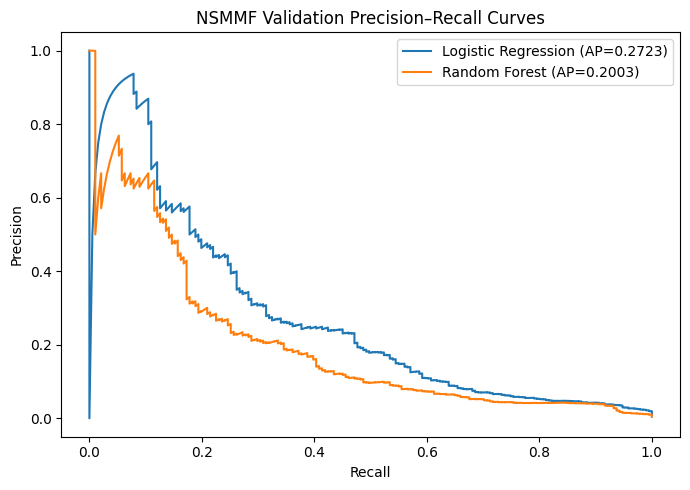

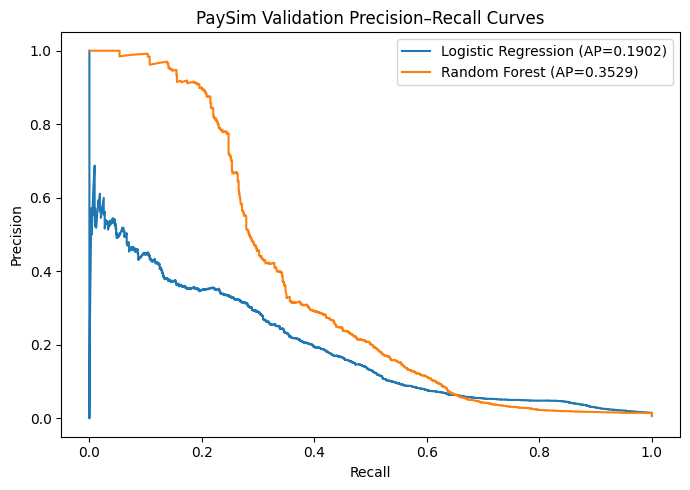

In [ ]:
plot_precision_recall_curves(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_supervised_valid_scores,
    "NSMMF Validation Precision–Recall Curves"
)

plot_precision_recall_curves(
    paysim_valid[PAYSIM_TARGET],
    paysim_supervised_valid_scores,
    "PaySim Validation Precision–Recall Curves"
)

#### 12.4.1 Feature importance and model interpretability

The following analyses are **interpretive only**. They do not alter the supervised-model choice, decision thresholds, anomaly detector, hybrid weights, or final test configuration.

For **NSMMF**, the selected supervised model is Logistic Regression, so the fitted coefficients are examined after preprocessing. Numeric predictors were standardised before fitting, which makes their coefficient magnitudes more comparable. One-hot encoded categorical terms are also shown. Coefficient sign and magnitude describe association with the fitted fraud score; they should not be interpreted as causal effects or as perfectly calibrated fraud probabilities.

For **PaySim**, raw-feature importance is estimated using **permutation importance on validation data**, scored by Average Precision. Each feature is shuffled while the already-fitted selected supervised model remains fixed. A larger reduction in Average Precision indicates that the model relied more heavily on that feature. A fixed validation subsample is used only to keep this diagnostic computationally practical; it does not affect model fitting or model selection.


NSMMF Logistic Regression: strongest transformed coefficient per raw feature


,raw_feature,term,coefficient,abs_coefficient
0,is_new_recipient,is_new_recipient,3.8761,3.8761
1,transaction_type,transaction_type=CASH_IN,-2.5756,2.5756
2,device_type,device_type=feature_phone,-1.7367,1.7367
3,initiation_channel,initiation_channel=APP,-1.6295,1.6295
4,receiver_state,receiver_state=Akwa Ibom,-1.2689,1.2689
5,urban_rural,urban_rural=rural,-1.1720,1.1720
6,transaction_state,transaction_state=Gombe,-0.7964,0.7964
7,sender_state,sender_state=Gombe,-0.7461,0.7461
8,geo_zone,geo_zone=North Central,-0.7420,0.7420
9,receiver_incoming_tx_24h,receiver_incoming_tx_24h,-0.6799,0.6799



Largest positive coefficient terms:


,raw_feature,term,coefficient
19,is_new_recipient,is_new_recipient,3.8761
36,transaction_type,transaction_type=P2P_TRANSFER,1.6313
105,receiver_state,receiver_state=Ondo,0.7914
81,receiver_state,receiver_state=Bauchi,0.6936
84,receiver_state,receiver_state=Borno,0.6879
25,receiver_unique_senders_24h,receiver_unique_senders_24h,0.6461
91,receiver_state,receiver_state=FCT,0.5899
5,is_new_device,is_new_device,0.5201
86,receiver_state,receiver_state=Delta,0.4954
29,agent_unique_customers_today,agent_unique_customers_today,0.4648



Largest negative coefficient terms:


,raw_feature,term,coefficient
33,transaction_type,transaction_type=CASH_IN,-2.5756
160,device_type,device_type=feature_phone,-1.7367
38,initiation_channel,initiation_channel=APP,-1.6295
39,initiation_channel,initiation_channel=USSD,-1.4736
161,device_type,device_type=smartphone,-1.4364
79,receiver_state,receiver_state=Akwa Ibom,-1.2689
157,urban_rural,urban_rural=rural,-1.1720
159,urban_rural,urban_rural=urban,-1.1679
80,receiver_state,receiver_state=Anambra,-0.8779
158,urban_rural,urban_rural=semi_urban,-0.8332


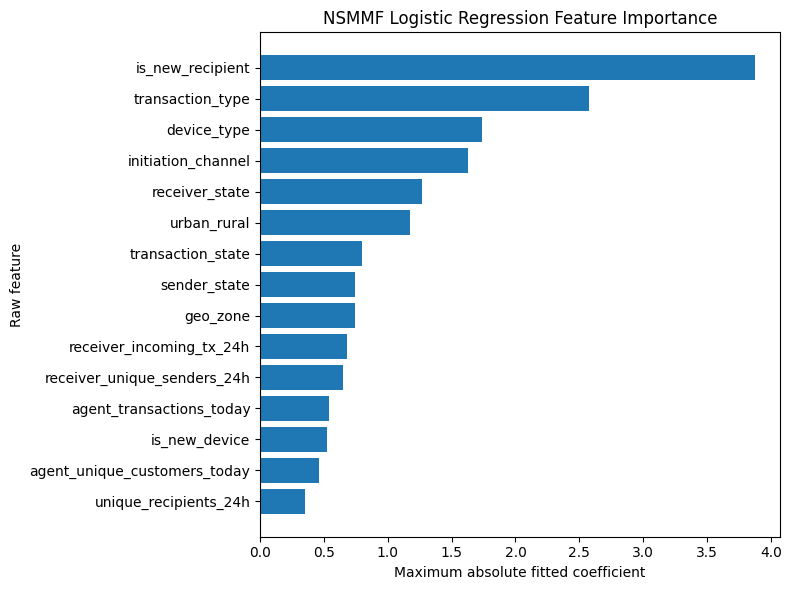

In [ ]:
from sklearn.inspection import permutation_importance


def logistic_term_coefficients(fitted_pipeline):
    # Reconstruct readable coefficient labels from the fitted preprocessing
    # pipeline and return one row per transformed Logistic Regression term.
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    estimator = fitted_pipeline.named_steps["model"]

    if not isinstance(estimator, LogisticRegression):
        raise TypeError(
            "This coefficient analysis expects a LogisticRegression model."
        )

    numeric_cols = list(preprocessor.transformers_[0][2])
    categorical_cols = list(preprocessor.transformers_[1][2])

    categorical_pipe = preprocessor.named_transformers_["cat"]
    onehot = categorical_pipe.named_steps["onehot"]

    term_labels = []
    raw_features = []

    for col in numeric_cols:
        term_labels.append(col)
        raw_features.append(col)

    for col, categories in zip(categorical_cols, onehot.categories_):
        for category in categories:
            term_labels.append(f"{col}={category}")
            raw_features.append(col)

    coefficients = estimator.coef_.ravel()

    if len(term_labels) != len(coefficients):
        raise ValueError(
            "Coefficient labels do not match the transformed feature count."
        )

    result = pd.DataFrame({
        "raw_feature": raw_features,
        "term": term_labels,
        "coefficient": coefficients,
    })

    result["abs_coefficient"] = result["coefficient"].abs()
    return result


if nsmmf_best_supervised_name == "Logistic Regression":
    nsmmf_lr_terms = logistic_term_coefficients(
        nsmmf_best_supervised_model
    )

    strongest_idx = (
        nsmmf_lr_terms
        .groupby("raw_feature")["abs_coefficient"]
        .idxmax()
    )

    nsmmf_feature_importance = (
        nsmmf_lr_terms
        .loc[
            strongest_idx,
            [
                "raw_feature",
                "term",
                "coefficient",
                "abs_coefficient",
            ]
        ]
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    print(
        "NSMMF Logistic Regression: strongest transformed "
        "coefficient per raw feature"
    )

    display(
        nsmmf_feature_importance
        .head(15)
        .round(4)
    )

    print("\nLargest positive coefficient terms:")
    display(
        nsmmf_lr_terms
        .sort_values("coefficient", ascending=False)
        .head(10)[
            ["raw_feature", "term", "coefficient"]
        ]
        .round(4)
    )

    print("\nLargest negative coefficient terms:")
    display(
        nsmmf_lr_terms
        .sort_values("coefficient", ascending=True)
        .head(10)[
            ["raw_feature", "term", "coefficient"]
        ]
        .round(4)
    )

    plot_data = (
        nsmmf_feature_importance
        .head(15)
        .sort_values("abs_coefficient")
    )

    plt.figure(figsize=(8, 6))
    plt.barh(
        plot_data["raw_feature"],
        plot_data["abs_coefficient"]
    )
    plt.xlabel("Maximum absolute fitted coefficient")
    plt.ylabel("Raw feature")
    plt.title("NSMMF Logistic Regression Feature Importance")
    plt.tight_layout()
    plt.show()

else:
    print(
        "NSMMF selected supervised model is not Logistic Regression; "
        "coefficient analysis skipped."
    )


PaySim permutation importance (validation diagnostic sample: 50,000 rows)


,feature,mean_ap_drop,std_ap_drop
0,amount,0.28669,0.00039
1,type,0.27072,0.01038
2,hour,0.16401,0.00589
3,is_night,0.05133,0.00198
4,day,0.00000,0.00000


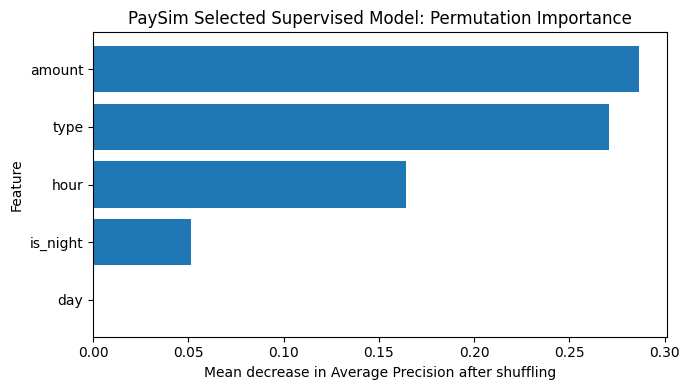

In [ ]:
PAYSIM_IMPORTANCE_VALID_ROWS = min(
    50_000,
    len(paysim_valid)
)

paysim_importance_valid = (
    paysim_valid
    .sample(
        n=PAYSIM_IMPORTANCE_VALID_ROWS,
        random_state=RANDOM_STATE
    )
    .copy()
)

if paysim_importance_valid[PAYSIM_TARGET].nunique() < 2:
    raise ValueError(
        "PaySim importance sample contains only one class."
    )

paysim_perm = permutation_importance(
    paysim_best_supervised_model,
    paysim_importance_valid[PAYSIM_CORE_FEATURES],
    paysim_importance_valid[PAYSIM_TARGET],
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

paysim_permutation_importance = (
    pd.DataFrame({
        "feature": PAYSIM_CORE_FEATURES,
        "mean_ap_drop": paysim_perm.importances_mean,
        "std_ap_drop": paysim_perm.importances_std,
    })
    .sort_values("mean_ap_drop", ascending=False)
    .reset_index(drop=True)
)

print(
    "PaySim permutation importance "
    f"(validation diagnostic sample: "
    f"{len(paysim_importance_valid):,} rows)"
)

display(
    paysim_permutation_importance.round(5)
)

plot_data = (
    paysim_permutation_importance
    .sort_values("mean_ap_drop")
)

plt.figure(figsize=(7, 4))
plt.barh(
    plot_data["feature"],
    plot_data["mean_ap_drop"]
)
plt.xlabel("Mean decrease in Average Precision after shuffling")
plt.ylabel("Feature")
plt.title(
    "PaySim Selected Supervised Model: Permutation Importance"
)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# PRINT 12.4.1 INTERPRETABILITY RESULTS AS PLAIN TEXT
# ============================================================

print("=" * 78)
print("NSMMF — STRONGEST COEFFICIENT PER RAW FEATURE")
print("=" * 78)

print(
    nsmmf_feature_importance
    .head(15)
    .round(4)
    .to_string(index=False)
)


print()
print("=" * 78)
print("NSMMF — LARGEST POSITIVE LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 78)

print(
    nsmmf_lr_terms
    .sort_values("coefficient", ascending=False)
    .head(10)[
        ["raw_feature", "term", "coefficient"]
    ]
    .round(4)
    .to_string(index=False)
)


print()
print("=" * 78)
print("NSMMF — LARGEST NEGATIVE LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 78)

print(
    nsmmf_lr_terms
    .sort_values("coefficient", ascending=True)
    .head(10)[
        ["raw_feature", "term", "coefficient"]
    ]
    .round(4)
    .to_string(index=False)
)


print()
print("=" * 78)
print("PAYSIM — PERMUTATION IMPORTANCE")
print("=" * 78)

print(
    paysim_permutation_importance
    .round(5)
    .to_string(index=False)
)

NSMMF — STRONGEST COEFFICIENT PER RAW FEATURE
                 raw_feature                         term  coefficient  abs_coefficient
            is_new_recipient             is_new_recipient       3.8761           3.8761
            transaction_type     transaction_type=CASH_IN      -2.5756           2.5756
                 device_type    device_type=feature_phone      -1.7367           1.7367
          initiation_channel       initiation_channel=APP      -1.6295           1.6295
              receiver_state     receiver_state=Akwa Ibom      -1.2689           1.2689
                 urban_rural            urban_rural=rural      -1.1720           1.1720
           transaction_state      transaction_state=Gombe      -0.7964           0.7964
                sender_state           sender_state=Gombe      -0.7461           0.7461
                    geo_zone       geo_zone=North Central      -0.7420           0.7420
    receiver_incoming_tx_24h     receiver_incoming_tx_24h      -0.6799    

>PaySim permutation importance provided a complementary interpretation of the selected Random Forest. When features were shuffled on validation data and performance was measured using Average Precision, `amount` produced the largest reduction (0.2867), followed closely by `transaction type` (0.2707) and simulated `hour` (0.1640). `is_night` had a smaller contribution (0.0513), while `day` contributed essentially no measurable importance. This indicates that the leakage-reduced PaySim model relies primarily on transaction value and transaction type, with simulated time-of-day providing additional information.

#### 12.4.2 Supervised-score calibration diagnostic

Because class weighting and fraud-preserving sampling can affect probability
calibration, the selected supervised models are evaluated using Brier score
and reliability curves on validation data.

This analysis is diagnostic only. No recalibration is performed and the
results do not alter model selection or decision thresholds. Lower Brier
scores indicate smaller squared probability errors.

The PaySim final hybrid is not included because it combines a supervised
score with an Isolation Forest anomaly percentile and is therefore treated
as a composite fraud-risk score rather than a calibrated probability.

,dataset,model,brier_score
0,NSMMF,Logistic Regression,0.062469
1,PaySim,Random Forest,0.048301


<Figure size 600x500 with 0 Axes>

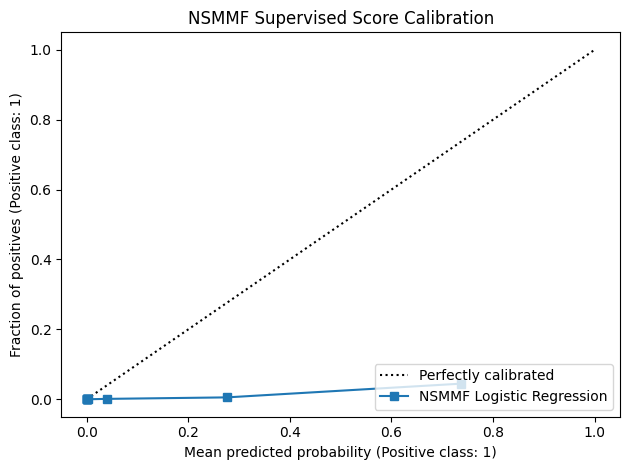

<Figure size 600x500 with 0 Axes>

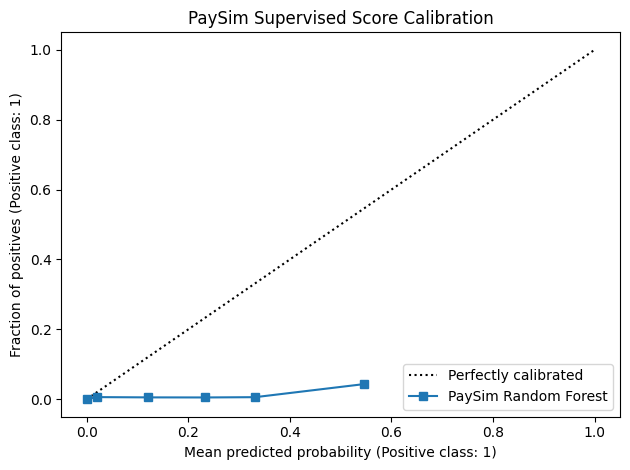

In [ ]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

calibration_results = pd.DataFrame([
    {
        "dataset": "NSMMF",
        "model": nsmmf_best_supervised_name,
        "brier_score": brier_score_loss(
            nsmmf_valid[NSMMF_TARGET],
            nsmmf_best_supervised_valid_score
        ),
    },
    {
        "dataset": "PaySim",
        "model": paysim_best_supervised_name,
        "brier_score": brier_score_loss(
            paysim_valid[PAYSIM_TARGET],
            paysim_best_supervised_valid_score
        ),
    },
])

display(calibration_results.round(6))


plt.figure(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_best_supervised_valid_score,
    n_bins=10,
    strategy="quantile",
    name="NSMMF Logistic Regression"
)

plt.title("NSMMF Supervised Score Calibration")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    paysim_valid[PAYSIM_TARGET],
    paysim_best_supervised_valid_score,
    n_bins=10,
    strategy="quantile",
    name="PaySim Random Forest"
)

plt.title("PaySim Supervised Score Calibration")
plt.tight_layout()
plt.show()

### 12.5 Precision–Recall threshold analysis

A fixed threshold of 0.50 is not automatically optimal for an imbalanced fraud detector.

For the selected supervised model, two validation-derived operating points are reported:

1. **Maximum-F1 threshold** — used as the neutral final supervised threshold in this notebook.
2. **High-recall threshold** — the highest-precision threshold that still achieves at least 90% validation recall, where possible.

The high-recall option is shown because real fraud operations may value missed-fraud reduction more strongly than overall F1. The test set is not used to choose either threshold.

In [ ]:
TARGET_RECALL = 0.90

nsmmf_best_f1_point = best_f1_threshold(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_best_supervised_valid_score
)

paysim_best_f1_point = best_f1_threshold(
    paysim_valid[PAYSIM_TARGET],
    paysim_best_supervised_valid_score
)

nsmmf_high_recall_point = high_recall_threshold(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_best_supervised_valid_score,
    target_recall=TARGET_RECALL
)

paysim_high_recall_point = high_recall_threshold(
    paysim_valid[PAYSIM_TARGET],
    paysim_best_supervised_valid_score,
    target_recall=TARGET_RECALL
)

nsmmf_supervised_threshold = float(
    nsmmf_best_f1_point["threshold"]
)

paysim_supervised_threshold = float(
    paysim_best_f1_point["threshold"]
)

threshold_summary = pd.DataFrame([
    {
        "dataset": "NSMMF",
        "model": nsmmf_best_supervised_name,
        "operating_point": "Max F1",
        **nsmmf_best_f1_point,
    },
    {
        "dataset": "NSMMF",
        "model": nsmmf_best_supervised_name,
        "operating_point": "Recall >= 0.90",
        **(nsmmf_high_recall_point or {}),
    },
    {
        "dataset": "PaySim",
        "model": paysim_best_supervised_name,
        "operating_point": "Max F1",
        **paysim_best_f1_point,
    },
    {
        "dataset": "PaySim",
        "model": paysim_best_supervised_name,
        "operating_point": "Recall >= 0.90",
        **(paysim_high_recall_point or {}),
    },
])

display(threshold_summary.round(4))

,dataset,model,operating_point,threshold,precision,recall,f1
0,NSMMF,Logistic Regression,Max F1,0.9842,0.4434,0.2461,0.3165
1,NSMMF,Logistic Regression,Recall >= 0.90,0.4894,0.0426,0.9005,0.0814
2,PaySim,Random Forest,Max F1,0.9465,0.6667,0.2636,0.3778
3,PaySim,Random Forest,Recall >= 0.90,0.1605,0.0174,0.9005,0.0341


In [ ]:
supervised_threshold_validation_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_valid[NSMMF_TARGET],
        nsmmf_best_supervised_valid_score,
        threshold=nsmmf_supervised_threshold,
        dataset="NSMMF",
        model=f"{nsmmf_best_supervised_name} (tuned)"
    ),
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_best_supervised_valid_score,
        threshold=paysim_supervised_threshold,
        dataset="PaySim",
        model=f"{paysim_best_supervised_name} (tuned)"
    ),
])

display(
    supervised_threshold_validation_results.round(4)
)

,dataset,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,tn,fp,fn,tp,predicted_positive_rate
0,NSMMF,Logistic Regression (tuned),0.9842,0.9946,0.6222,0.4434,0.2461,0.3165,0.9625,0.2687,0.2723,37250,59,144,47,0.0028
1,PaySim,Random Forest (tuned),0.9465,0.9947,0.6314,0.6667,0.2636,0.3778,0.9123,0.3528,0.3529,189809,155,866,310,0.0024


### 12.6 Feature-ablation experiments

The ablation experiments answer a different question from ordinary model selection: **how much of the model's apparent performance depends on features that may be unusually strong because of the synthetic-data design?**

#### NSMMF
The Random Forest is evaluated with:

- all model-safe features;
- without `is_new_recipient`;
- without `location_changed`;
- without both shortcut candidates.

PR-AUC is the primary comparison metric so the conclusion does not depend on a separately tuned threshold for every ablation.

#### PaySim
The primary core feature set is compared with a sensitivity set that adds the balance and balance-error variables. A large improvement from those variables should be interpreted cautiously because the PaySim simulator documentation warns that cancelled fraudulent transactions affect balance fields.

In [ ]:
def validation_ablation_result(
    model,
    valid_df,
    feature_cols,
    target_col,
    dataset,
    experiment_name
):
    score = probability_scores(
        model,
        valid_df[feature_cols]
    )

    metrics = evaluate_binary_scores(
        valid_df[target_col],
        score,
        threshold=0.50,
        dataset=dataset,
        model=experiment_name
    )

    return metrics, score

In [ ]:
nsmmf_ablation_rows = []
nsmmf_ablation_models = {}
nsmmf_ablation_scores = {}

# Reuse the already-fitted all-feature Random Forest.
base_metrics, base_score = validation_ablation_result(
    nsmmf_random_forest,
    nsmmf_valid,
    nsmmf_predictor_cols,
    NSMMF_TARGET,
    "NSMMF",
    "all_features"
)

nsmmf_ablation_rows.append(base_metrics)
nsmmf_ablation_models["all_features"] = nsmmf_random_forest
nsmmf_ablation_scores["all_features"] = base_score

for experiment_name, feature_cols in NSMMF_ABLATION_SETS.items():

    if experiment_name == "all_features":
        continue

    model = make_random_forest_pipeline(
        nsmmf_rf_train,
        feature_cols
    )

    model.fit(
        nsmmf_rf_train[feature_cols],
        nsmmf_rf_train[NSMMF_TARGET]
    )

    metrics, score = validation_ablation_result(
        model,
        nsmmf_valid,
        feature_cols,
        NSMMF_TARGET,
        "NSMMF",
        experiment_name
    )

    nsmmf_ablation_rows.append(metrics)
    nsmmf_ablation_models[experiment_name] = model
    nsmmf_ablation_scores[experiment_name] = score

nsmmf_ablation_results = (
    pd.DataFrame(nsmmf_ablation_rows)
    .sort_values("pr_auc", ascending=False)
)

display(
    nsmmf_ablation_results[
        [
            "model",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "average_precision",
        ]
    ].round(4)
)

,model,precision,recall,f1,roc_auc,pr_auc,average_precision
0,all_features,0.1314,0.4188,0.2000,0.9425,0.1981,0.2003
2,without_location_changed,0.1325,0.4188,0.2013,0.9381,0.1834,0.1855
1,without_new_recipient,0.1078,0.3037,0.1591,0.8473,0.1229,0.1244
3,without_both_shortcuts,0.1093,0.3089,0.1614,0.8418,0.1067,0.1100


In [ ]:
# PaySim sensitivity comparison using the same sampled RF training rows.

paysim_core_sensitivity_model = paysim_random_forest

paysim_balance_sensitivity_model = make_random_forest_pipeline(
    paysim_rf_train,
    PAYSIM_SENSITIVITY_FEATURES
)

paysim_balance_sensitivity_model.fit(
    paysim_rf_train[PAYSIM_SENSITIVITY_FEATURES],
    paysim_rf_train[PAYSIM_TARGET]
)

paysim_core_sensitivity_score = probability_scores(
    paysim_core_sensitivity_model,
    paysim_valid[PAYSIM_CORE_FEATURES]
)

paysim_balance_sensitivity_score = probability_scores(
    paysim_balance_sensitivity_model,
    paysim_valid[PAYSIM_SENSITIVITY_FEATURES]
)

paysim_sensitivity_results = pd.DataFrame([
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_core_sensitivity_score,
        threshold=0.50,
        dataset="PaySim",
        model="Core features"
    ),
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_balance_sensitivity_score,
        threshold=0.50,
        dataset="PaySim",
        model="Core + balance sensitivity features"
    ),
])

display(
    paysim_sensitivity_results[
        [
            "model",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "average_precision",
        ]
    ].round(4)
)

,model,precision,recall,f1,roc_auc,pr_auc,average_precision
0,Core features,0.0884,0.6276,0.1549,0.9123,0.3528,0.3529
1,Core + balance sensitivity features,1.0000,0.9991,0.9996,1.0000,1.0000,1.0000


### 12.7 Isolation Forest anomaly detector

Isolation Forest provides an unsupervised view of transaction risk.

To avoid teaching the anomaly detector known fraud patterns:

- it is fitted only on **legitimate training transactions**;
- its preprocessing is also fitted only on those legitimate training transactions;
- validation labels are used only after fitting, to evaluate the anomaly scores and choose an operating threshold.

For NSMMF, `is_new_recipient` and `location_changed` are excluded from the anomaly feature set so the anomaly score is less dependent on the two identified synthetic-shortcut candidates.

The raw Isolation Forest output is converted into an **anomaly percentile** relative to legitimate training activity. Values closer to 1 indicate greater abnormality.

In [ ]:
NSMMF_IF_FEATURES = (
    NSMMF_ABLATION_SETS[
        "without_both_shortcuts"
    ]
)

PAYSIM_IF_FEATURES = PAYSIM_CORE_FEATURES

def fit_isolation_forest_bundle(
    train_df,
    feature_cols,
    target_col,
    normal_cap,
):
    legitimate = train_df[
        train_df[target_col] == 0
    ].copy()

    if (
        normal_cap is not None
        and len(legitimate) > normal_cap
    ):
        legitimate = legitimate.sample(
            n=normal_cap,
            random_state=RANDOM_STATE
        )

    preprocessor = build_preprocessor(
        legitimate,
        feature_cols,
        scale_numeric=True
    )

    X_normal = preprocessor.fit_transform(
        legitimate[feature_cols]
    )

    max_samples = min(
        10_000,
        len(legitimate)
    )

    detector = IsolationForest(
        n_estimators=250,
        max_samples=max_samples,
        contamination="auto",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    detector.fit(X_normal)

    # Larger values should represent more anomalous transactions.
    normal_raw_anomaly = -detector.decision_function(
        X_normal
    )

    reference_sorted = np.sort(
        normal_raw_anomaly
    )

    return {
        "preprocessor": preprocessor,
        "detector": detector,
        "feature_cols": feature_cols,
        "reference_sorted": reference_sorted,
        "normal_training_rows": len(legitimate),
    }


def isolation_percentile_score(bundle, df):
    X = bundle["preprocessor"].transform(
        df[bundle["feature_cols"]]
    )

    raw_anomaly = -bundle[
        "detector"
    ].decision_function(X)

    reference = bundle["reference_sorted"]

    percentile = np.searchsorted(
        reference,
        raw_anomaly,
        side="right"
    ) / len(reference)

    return percentile

>**Isolation Forest sampling:** The outer legitimate-training cap controls the size and diversity of the normal-behaviour reference pool. Isolation Forest additionally performs internal subsampling, with `max_samples` limited to 10,000 observations per tree. The anomaly percentile is subsequently calibrated against scores from the larger legitimate reference pool. Therefore, increasing the outer cap does not mean that every tree is trained on all 500,000 legitimate observations.





In [ ]:
nsmmf_isolation_bundle = fit_isolation_forest_bundle(
    nsmmf_train,
    NSMMF_IF_FEATURES,
    NSMMF_TARGET,
    NSMMF_IF_NORMAL_CAP
)

paysim_isolation_bundle = fit_isolation_forest_bundle(
    paysim_train,
    PAYSIM_IF_FEATURES,
    PAYSIM_TARGET,
    PAYSIM_IF_NORMAL_CAP
)

nsmmf_if_valid_score = isolation_percentile_score(
    nsmmf_isolation_bundle,
    nsmmf_valid
)

paysim_if_valid_score = isolation_percentile_score(
    paysim_isolation_bundle,
    paysim_valid
)

print(
    "NSMMF legitimate Isolation Forest training rows:",
    nsmmf_isolation_bundle["normal_training_rows"]
)
print(
    "PaySim legitimate Isolation Forest training rows:",
    paysim_isolation_bundle["normal_training_rows"]
)

NSMMF legitimate Isolation Forest training rows: 150000
PaySim legitimate Isolation Forest training rows: 500000


In [ ]:
nsmmf_if_best_point = best_f1_threshold(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_if_valid_score
)

paysim_if_best_point = best_f1_threshold(
    paysim_valid[PAYSIM_TARGET],
    paysim_if_valid_score
)

nsmmf_if_threshold = float(
    nsmmf_if_best_point["threshold"]
)

paysim_if_threshold = float(
    paysim_if_best_point["threshold"]
)

isolation_validation_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_valid[NSMMF_TARGET],
        nsmmf_if_valid_score,
        threshold=nsmmf_if_threshold,
        dataset="NSMMF",
        model="Isolation Forest"
    ),
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_if_valid_score,
        threshold=paysim_if_threshold,
        dataset="PaySim",
        model="Isolation Forest"
    ),
])

display(
    isolation_validation_results.round(4)
)

,dataset,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,tn,fp,fn,tp,predicted_positive_rate
0,NSMMF,Isolation Forest,0.9616,0.9539,0.5862,0.0253,0.2147,0.0453,0.6517,0.0128,0.0131,35731,1578,150,41,0.0432
1,PaySim,Isolation Forest,0.9994,0.9909,0.6371,0.2689,0.2789,0.2738,0.8594,0.1624,0.1615,189072,892,848,328,0.0064


### 12.8 Hybrid fraud-risk score

The hybrid score combines two complementary signals:

- **supervised fraud score** — patterns associated with labelled fraud;
- **anomaly percentile** — how unusual the transaction is relative to legitimate training behaviour.

For a supervised weight `w`:

`hybrid_score = w × supervised_score + (1 − w) × anomaly_score`

The weight is searched from 0 to 1 using **validation PR-AUC only**. After the weight is fixed, the hybrid classification threshold is chosen from the validation Precision–Recall curve using maximum F1.

A hybrid model is not assumed to be better automatically. Its validation performance is compared against the supervised model before it is selected as the final system.

In [ ]:
def tune_hybrid_weight(
    y_true,
    supervised_score,
    anomaly_score,
    weights=None
):
    if weights is None:
        weights = np.linspace(0, 1, 21)

    rows = []

    for w in weights:
        hybrid = (
            w * supervised_score
            + (1 - w) * anomaly_score
        )

        best_point = best_f1_threshold(
            y_true,
            hybrid
        )

        rows.append({
            "supervised_weight": float(w),
            "anomaly_weight": float(1 - w),
            "pr_auc": pr_auc_score(
                y_true,
                hybrid
            ),
            "average_precision": average_precision_score(
                y_true,
                hybrid
            ),
            "best_validation_f1": best_point["f1"],
            "best_f1_threshold": best_point["threshold"],
        })

    results = pd.DataFrame(rows)

    best = (
        results
        .sort_values(
            [
                "pr_auc",
                "best_validation_f1",
            ],
            ascending=False
        )
        .iloc[0]
    )

    return results, best

In [ ]:
nsmmf_hybrid_search, nsmmf_hybrid_choice = (
    tune_hybrid_weight(
        nsmmf_valid[NSMMF_TARGET],
        nsmmf_best_supervised_valid_score,
        nsmmf_if_valid_score
    )
)

paysim_hybrid_search, paysim_hybrid_choice = (
    tune_hybrid_weight(
        paysim_valid[PAYSIM_TARGET],
        paysim_best_supervised_valid_score,
        paysim_if_valid_score
    )
)

nsmmf_hybrid_weight = float(
    nsmmf_hybrid_choice[
        "supervised_weight"
    ]
)

paysim_hybrid_weight = float(
    paysim_hybrid_choice[
        "supervised_weight"
    ]
)

nsmmf_hybrid_valid_score = (
    nsmmf_hybrid_weight
    * nsmmf_best_supervised_valid_score
    + (1 - nsmmf_hybrid_weight)
    * nsmmf_if_valid_score
)

paysim_hybrid_valid_score = (
    paysim_hybrid_weight
    * paysim_best_supervised_valid_score
    + (1 - paysim_hybrid_weight)
    * paysim_if_valid_score
)

nsmmf_hybrid_point = best_f1_threshold(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_hybrid_valid_score
)

paysim_hybrid_point = best_f1_threshold(
    paysim_valid[PAYSIM_TARGET],
    paysim_hybrid_valid_score
)

nsmmf_hybrid_threshold = float(
    nsmmf_hybrid_point["threshold"]
)

paysim_hybrid_threshold = float(
    paysim_hybrid_point["threshold"]
)

print(
    "NSMMF supervised weight:",
    round(nsmmf_hybrid_weight, 3)
)
print(
    "NSMMF anomaly weight:",
    round(1 - nsmmf_hybrid_weight, 3)
)
print(
    "PaySim supervised weight:",
    round(paysim_hybrid_weight, 3)
)
print(
    "PaySim anomaly weight:",
    round(1 - paysim_hybrid_weight, 3)
)

NSMMF supervised weight: 1.0
NSMMF anomaly weight: 0.0
PaySim supervised weight: 0.1
PaySim anomaly weight: 0.9


In [ ]:
hybrid_validation_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_valid[NSMMF_TARGET],
        nsmmf_hybrid_valid_score,
        threshold=nsmmf_hybrid_threshold,
        dataset="NSMMF",
        model="Hybrid"
    ),
    evaluate_binary_scores(
        paysim_valid[PAYSIM_TARGET],
        paysim_hybrid_valid_score,
        threshold=paysim_hybrid_threshold,
        dataset="PaySim",
        model="Hybrid"
    ),
])

validation_system_comparison = pd.concat(
    [
        supervised_threshold_validation_results,
        isolation_validation_results,
        hybrid_validation_results,
    ],
    ignore_index=True
)

display(
    validation_system_comparison[
        [
            "dataset",
            "model",
            "threshold",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "average_precision",
            "fp",
            "fn",
        ]
    ]
    .sort_values(
        ["dataset", "pr_auc"],
        ascending=[True, False]
    )
    .round(4)
)

,dataset,model,threshold,precision,recall,f1,roc_auc,pr_auc,average_precision,fp,fn
0,NSMMF,Logistic Regression (tuned),0.9842,0.4434,0.2461,0.3165,0.9625,0.2687,0.2723,59,144
4,NSMMF,Hybrid,0.9842,0.4434,0.2461,0.3165,0.9625,0.2687,0.2723,59,144
2,NSMMF,Isolation Forest,0.9616,0.0253,0.2147,0.0453,0.6517,0.0128,0.0131,1578,150
5,PaySim,Hybrid,0.9835,0.5529,0.3512,0.4295,0.9282,0.3864,0.3865,334,763
1,PaySim,Random Forest (tuned),0.9465,0.6667,0.2636,0.3778,0.9123,0.3528,0.3529,155,866
3,PaySim,Isolation Forest,0.9994,0.2689,0.2789,0.2738,0.8594,0.1624,0.1615,892,848


In [ ]:
# Freeze the final system choice BEFORE looking at the test set.
# Isolation Forest remains an important component/benchmark,
# but the final predictive system is chosen between the
# selected supervised classifier and the proposed hybrid.

nsmmf_supervised_validation_pr_auc = pr_auc_score(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_best_supervised_valid_score
)

paysim_supervised_validation_pr_auc = pr_auc_score(
    paysim_valid[PAYSIM_TARGET],
    paysim_best_supervised_valid_score
)

nsmmf_hybrid_validation_pr_auc = pr_auc_score(
    nsmmf_valid[NSMMF_TARGET],
    nsmmf_hybrid_valid_score
)

paysim_hybrid_validation_pr_auc = pr_auc_score(
    paysim_valid[PAYSIM_TARGET],
    paysim_hybrid_valid_score
)

nsmmf_final_system = (
    "Hybrid"
    if nsmmf_hybrid_validation_pr_auc
    > nsmmf_supervised_validation_pr_auc
    else "Supervised"
)

paysim_final_system = (
    "Hybrid"
    if paysim_hybrid_validation_pr_auc
    > paysim_supervised_validation_pr_auc
    else "Supervised"
)

print(
    "Frozen NSMMF final system:",
    nsmmf_final_system
)
print(
    "Frozen PaySim final system:",
    paysim_final_system
)

Frozen NSMMF final system: Supervised
Frozen PaySim final system: Hybrid


### 12.9 Final untouched test-set evaluation

Only now are the chronological test sets scored.

No model, threshold, hybrid weight, or anomaly threshold is changed after viewing these results.

Three systems are reported for transparency:

- selected supervised classifier;
- Isolation Forest anomaly detector;
- hybrid fraud-risk score.

The previously frozen validation-based final-system choice is highlighted separately.

In [ ]:
# -------------------------------
# NSMMF test scores
# -------------------------------

nsmmf_supervised_test_score = probability_scores(
    nsmmf_best_supervised_model,
    nsmmf_test[nsmmf_predictor_cols]
)

nsmmf_if_test_score = isolation_percentile_score(
    nsmmf_isolation_bundle,
    nsmmf_test
)

nsmmf_hybrid_test_score = (
    nsmmf_hybrid_weight
    * nsmmf_supervised_test_score
    + (1 - nsmmf_hybrid_weight)
    * nsmmf_if_test_score
)

# -------------------------------
# PaySim test scores
# -------------------------------

paysim_supervised_test_score = probability_scores(
    paysim_best_supervised_model,
    paysim_test[PAYSIM_CORE_FEATURES]
)

paysim_if_test_score = isolation_percentile_score(
    paysim_isolation_bundle,
    paysim_test
)

paysim_hybrid_test_score = (
    paysim_hybrid_weight
    * paysim_supervised_test_score
    + (1 - paysim_hybrid_weight)
    * paysim_if_test_score
)

In [ ]:
final_test_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_test[NSMMF_TARGET],
        nsmmf_supervised_test_score,
        threshold=nsmmf_supervised_threshold,
        dataset="NSMMF",
        model=f"Supervised: {nsmmf_best_supervised_name}"
    ),
    evaluate_binary_scores(
        nsmmf_test[NSMMF_TARGET],
        nsmmf_if_test_score,
        threshold=nsmmf_if_threshold,
        dataset="NSMMF",
        model="Isolation Forest"
    ),
    evaluate_binary_scores(
        nsmmf_test[NSMMF_TARGET],
        nsmmf_hybrid_test_score,
        threshold=nsmmf_hybrid_threshold,
        dataset="NSMMF",
        model="Hybrid"
    ),
    evaluate_binary_scores(
        paysim_test[PAYSIM_TARGET],
        paysim_supervised_test_score,
        threshold=paysim_supervised_threshold,
        dataset="PaySim",
        model=f"Supervised: {paysim_best_supervised_name}"
    ),
    evaluate_binary_scores(
        paysim_test[PAYSIM_TARGET],
        paysim_if_test_score,
        threshold=paysim_if_threshold,
        dataset="PaySim",
        model="Isolation Forest"
    ),
    evaluate_binary_scores(
        paysim_test[PAYSIM_TARGET],
        paysim_hybrid_test_score,
        threshold=paysim_hybrid_threshold,
        dataset="PaySim",
        model="Hybrid"
    ),
])

display(
    final_test_results[
        [
            "dataset",
            "model",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "average_precision",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ].round(4)
)

,dataset,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,tn,fp,fn,tp
0,NSMMF,Supervised: Logistic Regression,0.9842,0.9955,0.6409,0.4845,0.2831,0.3574,0.9663,0.2938,0.2980,37284,50,119,47
1,NSMMF,Isolation Forest,0.9616,0.9507,0.5554,0.0150,0.1566,0.0273,0.6671,0.0120,0.0123,35624,1710,140,26
2,NSMMF,Hybrid,0.9842,0.9955,0.6409,0.4845,0.2831,0.3574,0.9663,0.2938,0.2980,37284,50,119,47
3,PaySim,Supervised: Random Forest,0.9465,0.9876,0.6238,0.6373,0.2496,0.3587,0.8993,0.3296,0.3297,88037,177,935,311
4,PaySim,Isolation Forest,0.9994,0.9859,0.6067,0.4839,0.2167,0.2993,0.8510,0.2683,0.2676,87926,288,976,270
5,PaySim,Hybrid,0.9835,0.9890,0.6605,0.7376,0.3226,0.4489,0.9179,0.4257,0.4258,88071,143,844,402


In [ ]:
# Final predictions from the systems frozen on validation data.

if nsmmf_final_system == "Hybrid":
    nsmmf_final_test_score = nsmmf_hybrid_test_score
    nsmmf_final_threshold = nsmmf_hybrid_threshold
else:
    nsmmf_final_test_score = nsmmf_supervised_test_score
    nsmmf_final_threshold = nsmmf_supervised_threshold

nsmmf_final_test_pred = (
    nsmmf_final_test_score
    >= nsmmf_final_threshold
).astype(int)


if paysim_final_system == "Hybrid":
    paysim_final_test_score = paysim_hybrid_test_score
    paysim_final_threshold = paysim_hybrid_threshold
else:
    paysim_final_test_score = paysim_supervised_test_score
    paysim_final_threshold = paysim_supervised_threshold

paysim_final_test_pred = (
    paysim_final_test_score
    >= paysim_final_threshold
).astype(int)

final_selected_test_results = pd.DataFrame([
    evaluate_binary_scores(
        nsmmf_test[NSMMF_TARGET],
        nsmmf_final_test_score,
        threshold=nsmmf_final_threshold,
        dataset="NSMMF",
        model=f"FINAL: {nsmmf_final_system}"
    ),
    evaluate_binary_scores(
        paysim_test[PAYSIM_TARGET],
        paysim_final_test_score,
        threshold=paysim_final_threshold,
        dataset="PaySim",
        model=f"FINAL: {paysim_final_system}"
    ),
])

display(
    final_selected_test_results.round(4)
)

,dataset,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,average_precision,tn,fp,fn,tp,predicted_positive_rate
0,NSMMF,FINAL: Supervised,0.9842,0.9955,0.6409,0.4845,0.2831,0.3574,0.9663,0.2938,0.2980,37284,50,119,47,0.0026
1,PaySim,FINAL: Hybrid,0.9835,0.9890,0.6605,0.7376,0.3226,0.4489,0.9179,0.4257,0.4258,88071,143,844,402,0.0061


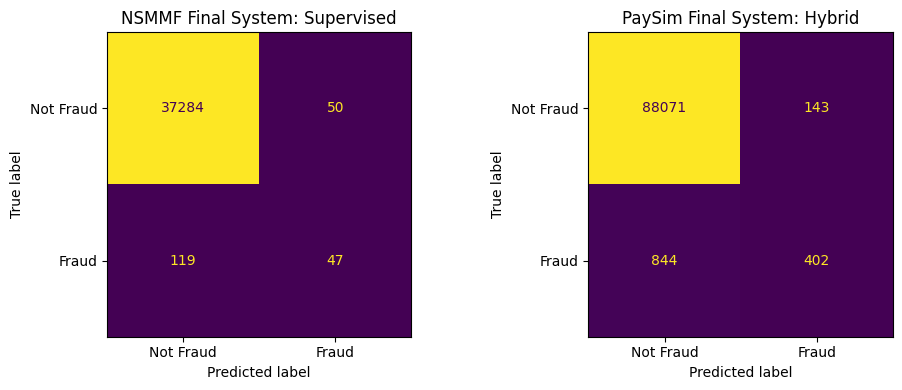

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

ConfusionMatrixDisplay.from_predictions(
    nsmmf_test[NSMMF_TARGET],
    nsmmf_final_test_pred,
    display_labels=["Not Fraud", "Fraud"],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title(
    f"NSMMF Final System: {nsmmf_final_system}"
)

ConfusionMatrixDisplay.from_predictions(
    paysim_test[PAYSIM_TARGET],
    paysim_final_test_pred,
    display_labels=["Not Fraud", "Fraud"],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(
    f"PaySim Final System: {paysim_final_system}"
)

plt.tight_layout()
plt.show()

>**Operational interpretation:** The principal weakness of the final systems is Recall. At their validation-selected maximum-F1 operating points, the NSMMF classifier detected 28.31% of fraud cases and the PaySim hybrid detected 32.26%. Thus, approximately 71.7% and 67.7% of fraud cases, respectively, were missed. The models therefore demonstrate useful risk-ranking and alert-prioritisation capability, but the current configurations would not be suitable as standalone automatic fraud-blocking systems.

### 12.10 NSMMF recall by fraud scenario

Overall Recall can hide important weaknesses. NSMMF contains seven audit-only fraud scenarios, so the final frozen NSMMF test predictions are evaluated separately by fraud type.

`fraud_type` is **never used as a model input**. It is attached only after prediction for post-hoc evaluation.

Because `nsmmf_ml.csv` and `nsmmf_full.csv` originate from the same generated transaction sequence, fraud-scenario metadata are attached post hoc using shared transaction attributes rather than positional row order. The merge is validated as one-to-one and preserves the exact order of `nsmmf_test`, ensuring that each frozen test prediction is associated with the correct fraud scenario.

Additional validation checks confirm that the number of matched test transactions is unchanged and that all fraudulent test transactions are successfully associated with a fraud scenario before scenario-level Recall is reported.

In [ ]:
# ============================================================
# NSMMF RECALL BY FRAUD SCENARIO — ROBUST AUDIT ALIGNMENT
# ============================================================

# fraud_type is audit-only and is never used as a model feature.
#
# Instead of assuming nsmmf_ml.csv and nsmmf_full.csv remain in
# identical row order, match the audit metadata back to the
# existing nsmmf_test rows using transaction characteristics.

# Use columns that exist in both files and were NOT changed
# during NSMMF cleaning.
#
# minutes_since_recent_incoming is excluded because the cleaning
# stage converts its 999999 sentinel values to NaN.
audit_key_cols = [
    c for c in nsmmf.columns
    if (
        c in nsmmf_full.columns
        and c != "minutes_since_recent_incoming"
    )
]

print("Audit matching columns:", len(audit_key_cols))


# ------------------------------------------------------------
# 1. Build audit lookup from the full dataset
# ------------------------------------------------------------

audit_lookup = nsmmf_full[
    audit_key_cols + ["fraud_type"]
].copy()


# Check whether our matching key uniquely identifies transactions
audit_duplicate_keys = audit_lookup.duplicated(
    subset=audit_key_cols
).sum()

test_duplicate_keys = nsmmf_test.duplicated(
    subset=audit_key_cols
).sum()

print("Duplicate audit keys:", audit_duplicate_keys)
print("Duplicate test keys:", test_duplicate_keys)

if audit_duplicate_keys > 0:
    raise ValueError(
        "The selected audit key does not uniquely identify "
        "transactions in nsmmf_full."
    )

if test_duplicate_keys > 0:
    raise ValueError(
        "The selected audit key does not uniquely identify "
        "transactions in nsmmf_test."
    )


# ------------------------------------------------------------
# 2. Preserve the EXACT order used for model predictions
# ------------------------------------------------------------

nsmmf_audit_test = nsmmf_test.copy()

nsmmf_audit_test["_prediction_order"] = np.arange(
    len(nsmmf_audit_test)
)


# ------------------------------------------------------------
# 3. Merge fraud_type onto the existing test rows
# ------------------------------------------------------------

nsmmf_audit_test = nsmmf_audit_test.merge(
    audit_lookup,
    on=audit_key_cols,
    how="left",
    validate="one_to_one",
    sort=False
)


# Restore prediction order explicitly
nsmmf_audit_test = (
    nsmmf_audit_test
    .sort_values("_prediction_order")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Validate alignment
# ------------------------------------------------------------

if len(nsmmf_audit_test) != len(nsmmf_test):
    raise ValueError(
        "Audit merge changed the number of NSMMF test rows."
    )

# Fraud rows must have a fraud scenario
missing_fraud_types = (
    (
        nsmmf_audit_test[NSMMF_TARGET] == 1
    )
    &
    (
        nsmmf_audit_test["fraud_type"].isna()
    )
).sum()

if missing_fraud_types > 0:
    raise ValueError(
        f"{missing_fraud_types} fraud test rows could not "
        "be matched to a fraud_type."
    )

print(
    "Audit alignment successful:",
    len(nsmmf_audit_test),
    "test transactions matched."
)


# ------------------------------------------------------------
# 5. Attach FINAL predictions
# ------------------------------------------------------------

if len(nsmmf_final_test_pred) != len(nsmmf_audit_test):
    raise ValueError(
        "Prediction count does not match NSMMF test rows."
    )

nsmmf_audit_test["final_prediction"] = (
    nsmmf_final_test_pred
)


# ------------------------------------------------------------
# 6. Keep only actual fraud transactions
# ------------------------------------------------------------

fraud_scenario_test = nsmmf_audit_test[
    nsmmf_audit_test[NSMMF_TARGET] == 1
].copy()


# ------------------------------------------------------------
# 7. Recall by fraud scenario
# ------------------------------------------------------------

scenario_recall = (
    fraud_scenario_test
    .groupby("fraud_type")
    .agg(
        fraud_cases=(NSMMF_TARGET, "size"),
        detected=("final_prediction", "sum"),
    )
)

scenario_recall["missed"] = (
    scenario_recall["fraud_cases"]
    - scenario_recall["detected"]
)

scenario_recall["recall"] = (
    scenario_recall["detected"]
    / scenario_recall["fraud_cases"]
)

scenario_recall = scenario_recall.sort_values(
    "recall",
    ascending=False
)

display(
    scenario_recall.round(4)
)

Audit matching columns: 39
Duplicate audit keys: 0
Duplicate test keys: 0
Audit alignment successful: 37500 test transactions matched.


,fraud_cases,detected,missed,recall
fraud_type,,,,
account_takeover,24,19,5,0.7917
sim_device_compromise,26,15,11,0.5769
velocity_fraud,10,2,8,0.2000
dormant_wallet_takeover,16,3,13,0.1875
mule_activity,29,5,24,0.1724
rapid_cashout,18,1,17,0.0556
social_engineering,43,2,41,0.0465


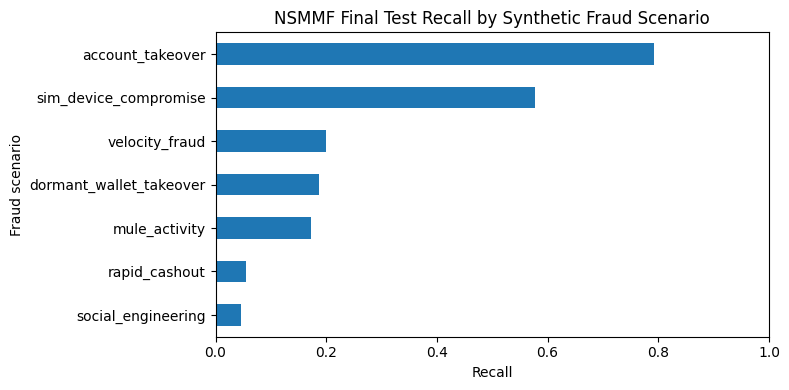

In [ ]:
plt.figure(figsize=(8, 4))

scenario_recall["recall"].sort_values().plot(
    kind="barh"
)

plt.xlim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Fraud scenario")
plt.title(
    "NSMMF Final Test Recall by Synthetic Fraud Scenario"
)
plt.tight_layout()
plt.show()

### 12.11 Post-hoc false-positive and false-negative analysis

The following error analysis is performed **after the final systems and thresholds have been frozen**. It is descriptive only: no feature, model, threshold, anomaly score, or hybrid weight is changed in response to these test-set patterns.

The purpose is to understand what the final systems tend to flag incorrectly and what kinds of fraud they tend to miss. For NSMMF, behavioural and device indicators are compared across false positives (FP), false negatives (FN), and true positives (TP). For PaySim, the same comparison focuses on transaction type, amount, and simulated-time variables.

This analysis should therefore be interpreted as an explanation of final test errors, not as an additional model-selection step.


In [ ]:
def add_prediction_outcome(
    df,
    target_col,
    prediction,
    score
):
    result = df.reset_index(drop=True).copy()

    actual = result[target_col].to_numpy().astype(int)
    prediction = np.asarray(prediction).astype(int)
    score = np.asarray(score, dtype=float)

    if not (
        len(result)
        == len(prediction)
        == len(score)
    ):
        raise ValueError(
            "Prediction/score lengths do not match the dataframe."
        )

    result["_actual"] = actual
    result["_prediction"] = prediction
    result["_score"] = score

    result["_outcome"] = np.select(
        [
            (actual == 0) & (prediction == 0),
            (actual == 0) & (prediction == 1),
            (actual == 1) & (prediction == 0),
            (actual == 1) & (prediction == 1),
        ],
        ["TN", "FP", "FN", "TP"],
        default="Unknown"
    )

    return result


nsmmf_error_test = add_prediction_outcome(
    nsmmf_test,
    NSMMF_TARGET,
    nsmmf_final_test_pred,
    nsmmf_final_test_score
)

paysim_error_test = add_prediction_outcome(
    paysim_test,
    PAYSIM_TARGET,
    paysim_final_test_pred,
    paysim_final_test_score
)


error_count_table = pd.DataFrame({
    "NSMMF": (
        nsmmf_error_test["_outcome"]
        .value_counts()
        .reindex(["TN", "FP", "FN", "TP"], fill_value=0)
    ),
    "PaySim": (
        paysim_error_test["_outcome"]
        .value_counts()
        .reindex(["TN", "FP", "FN", "TP"], fill_value=0)
    ),
})

print("Final test prediction outcomes:")
display(error_count_table)


focus_outcomes = ["FP", "FN", "TP"]

nsmmf_continuous_candidates = [
    "amount",
    "amount_deviation_ratio",
    "transactions_last_1h",
    "transactions_last_24h",
    "days_since_last_activity",
    "prior_failed_attempts_24h",
]

nsmmf_flag_candidates = [
    "is_new_recipient",
    "is_new_device",
    "location_changed",
    "is_unusual_hour",
    "sim_changed_last_7d",
    "is_weekend",
]

nsmmf_continuous_cols = [
    c for c in nsmmf_continuous_candidates
    if c in nsmmf_error_test.columns
]

nsmmf_flag_cols = [
    c for c in nsmmf_flag_candidates
    if c in nsmmf_error_test.columns
]

print("\nNSMMF: median continuous-feature profile")
nsmmf_error_numeric_profile = (
    nsmmf_error_test[
        nsmmf_error_test["_outcome"].isin(focus_outcomes)
    ]
    .groupby("_outcome")[nsmmf_continuous_cols]
    .median()
    .reindex(focus_outcomes)
)

display(
    nsmmf_error_numeric_profile.round(3)
)

print(
    "\nNSMMF: behavioural/device flag rates "
    "(proportion equal to 1)"
)
nsmmf_error_flag_profile = (
    nsmmf_error_test[
        nsmmf_error_test["_outcome"].isin(focus_outcomes)
    ]
    .groupby("_outcome")[nsmmf_flag_cols]
    .mean()
    .reindex(focus_outcomes)
)

display(
    nsmmf_error_flag_profile.round(3)
)

if "transaction_type" in nsmmf_error_test.columns:
    print(
        "\nNSMMF: transaction-type distribution within "
        "FP, FN and TP groups"
    )

    nsmmf_error_type_profile = (
        pd.crosstab(
            nsmmf_error_test["_outcome"],
            nsmmf_error_test["transaction_type"],
            normalize="index"
        )
        .reindex(focus_outcomes)
        .fillna(0)
    )

    display(
        nsmmf_error_type_profile.round(3)
    )


nsmmf_example_cols = [
    c for c in [
        "timestamp",
        "transaction_type",
        "amount",
        "amount_deviation_ratio",
        "is_new_recipient",
        "is_new_device",
        "location_changed",
        "transactions_last_1h",
        "_score",
        "_outcome",
    ]
    if c in nsmmf_error_test.columns
]

print("\nNSMMF: highest-scoring false positives")
display(
    nsmmf_error_test[
        nsmmf_error_test["_outcome"] == "FP"
    ]
    .nlargest(10, "_score")[nsmmf_example_cols]
    .round(4)
)

print(
    "\nNSMMF: highest-scoring missed fraud "
    "(false negatives closest to the threshold)"
)
display(
    nsmmf_error_test[
        nsmmf_error_test["_outcome"] == "FN"
    ]
    .nlargest(10, "_score")[nsmmf_example_cols]
    .round(4)
)


paysim_numeric_candidates = [
    "amount",
    "hour",
    "day",
]

paysim_numeric_cols = [
    c for c in paysim_numeric_candidates
    if c in paysim_error_test.columns
]

print("\nPaySim: median numeric profile")
paysim_error_numeric_profile = (
    paysim_error_test[
        paysim_error_test["_outcome"].isin(focus_outcomes)
    ]
    .groupby("_outcome")[paysim_numeric_cols]
    .median()
    .reindex(focus_outcomes)
)

display(
    paysim_error_numeric_profile.round(3)
)

if "is_night" in paysim_error_test.columns:
    print(
        "\nPaySim: night-transaction rate within "
        "FP, FN and TP groups"
    )

    paysim_night_profile = (
        paysim_error_test[
            paysim_error_test["_outcome"].isin(focus_outcomes)
        ]
        .groupby("_outcome")["is_night"]
        .mean()
        .reindex(focus_outcomes)
        .rename("is_night_rate")
        .to_frame()
    )

    display(
        paysim_night_profile.round(3)
    )

if "type" in paysim_error_test.columns:
    print(
        "\nPaySim: transaction-type distribution within "
        "FP, FN and TP groups"
    )

    paysim_error_type_profile = (
        pd.crosstab(
            paysim_error_test["_outcome"],
            paysim_error_test["type"],
            normalize="index"
        )
        .reindex(focus_outcomes)
        .fillna(0)
    )

    display(
        paysim_error_type_profile.round(3)
    )


paysim_example_cols = [
    c for c in [
        "step",
        "type",
        "amount",
        "hour",
        "day",
        "is_night",
        "_score",
        "_outcome",
    ]
    if c in paysim_error_test.columns
]

print("\nPaySim: highest-scoring false positives")
display(
    paysim_error_test[
        paysim_error_test["_outcome"] == "FP"
    ]
    .nlargest(10, "_score")[paysim_example_cols]
    .round(4)
)

print(
    "\nPaySim: highest-scoring missed fraud "
    "(false negatives closest to the threshold)"
)
display(
    paysim_error_test[
        paysim_error_test["_outcome"] == "FN"
    ]
    .nlargest(10, "_score")[paysim_example_cols]
    .round(4)
)


Final test prediction outcomes:


,NSMMF,PaySim
_outcome,,
TN,37284,88071
FP,50,143
FN,119,844
TP,47,402



NSMMF: median continuous-feature profile


,amount,amount_deviation_ratio,transactions_last_1h,transactions_last_24h,days_since_last_activity,prior_failed_attempts_24h
_outcome,,,,,,
FP,10500.0,1.342,0.0,0.0,1.274,0.0
FN,11000.0,1.413,0.0,0.0,2.458,0.0
TP,11000.0,1.602,0.0,0.0,2.764,0.0



NSMMF: behavioural/device flag rates (proportion equal to 1)


...

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
_outcome,,,,,
FP,0.0,0.049,0.0,0.0,0.951
FN,0.0,0.441,0.0,0.0,0.559
TP,0.0,0.617,0.0,0.0,0.383



PaySim: highest-scoring false positives


,step,type,amount,hour,day,is_night,_score,_outcome
23497,675,TRANSFER,9640565.000,2,29,1,1.0000,FP
78008,699,TRANSFER,1493437.625,2,30,1,0.9999,FP
77963,698,TRANSFER,1480533.000,1,30,1,0.9995,FP
77964,698,TRANSFER,1053469.125,1,30,1,0.9995,FP
77967,698,TRANSFER,1082562.375,1,30,1,0.9995,FP
77986,699,TRANSFER,1060258.625,2,30,1,0.9994,FP
77991,699,TRANSFER,1089273.125,2,30,1,0.9994,FP
77982,699,TRANSFER,808134.500,2,30,1,0.9994,FP
9101,656,TRANSFER,9952652.000,7,28,0,0.9986,FP
78006,699,TRANSFER,549094.500,2,30,1,0.9981,FP



PaySim: highest-scoring missed fraud (false negatives closest to the threshold)


,step,type,amount,hour,day,is_night,_score,_outcome
22968,672,TRANSFER,7.218629e+06,23,28,1,0.9834,FN
89344,733,CASH_OUT,9.059196e+05,12,31,0,0.9832,FN
89233,725,CASH_OUT,1.232592e+05,4,31,1,0.9829,FN
23601,680,TRANSFER,2.651994e+06,7,29,0,0.9829,FN
0,632,TRANSFER,8.220971e+04,7,27,0,0.9828,FN
53491,688,TRANSFER,7.442005e+06,15,29,0,0.9828,FN
8648,652,CASH_OUT,9.204322e+04,3,28,1,0.9827,FN
23504,676,CASH_OUT,1.715721e+05,3,29,1,0.9827,FN
23600,680,TRANSFER,2.254417e+06,7,29,0,0.9826,FN
89265,727,TRANSFER,8.153848e+05,6,31,0,0.9826,FN


### 12.12 Lightweight bootstrap uncertainty for final test metrics

Point estimates alone do not show how much uncertainty is associated with the final test results. A lightweight **stratified bootstrap** is therefore applied to the already-frozen test scores.

Fraud and legitimate observations are resampled separately with replacement so that each bootstrap replicate retains the observed test-set class counts. No model is retrained and no threshold is re-optimised. The resulting 95% intervals quantify resampling uncertainty for the **fixed final configuration**; they do not capture model-training variance across different random seeds or different datasets.


In [ ]:
BOOTSTRAP_REPLICATES = 200
BOOTSTRAP_CONFIDENCE = 0.95


def fixed_system_bootstrap_ci(
    y_true,
    y_score,
    threshold,
    n_boot=BOOTSTRAP_REPLICATES,
    confidence=BOOTSTRAP_CONFIDENCE,
    random_state=RANDOM_STATE,
):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)

    positive_idx = np.flatnonzero(y_true == 1)
    negative_idx = np.flatnonzero(y_true == 0)

    if len(positive_idx) == 0 or len(negative_idx) == 0:
        raise ValueError(
            "Bootstrap requires both fraud and legitimate observations."
        )

    rng = np.random.default_rng(random_state)
    rows = []

    for _ in range(n_boot):
        boot_positive = rng.choice(
            positive_idx,
            size=len(positive_idx),
            replace=True
        )

        boot_negative = rng.choice(
            negative_idx,
            size=len(negative_idx),
            replace=True
        )

        boot_idx = np.concatenate(
            [boot_positive, boot_negative]
        )

        rng.shuffle(boot_idx)

        y_b = y_true[boot_idx]
        score_b = y_score[boot_idx]
        pred_b = (score_b >= threshold).astype(int)

        rows.append({
            "precision": precision_score(
                y_b, pred_b, zero_division=0
            ),
            "recall": recall_score(
                y_b, pred_b, zero_division=0
            ),
            "f1": f1_score(
                y_b, pred_b, zero_division=0
            ),
            "roc_auc": safe_roc_auc(
                y_b, score_b
            ),
            "pr_auc": pr_auc_score(
                y_b, score_b
            ),
        })

    boot = pd.DataFrame(rows)
    alpha = (1 - confidence) / 2

    point_pred = (y_score >= threshold).astype(int)

    point = {
        "precision": precision_score(
            y_true, point_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, point_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, point_pred, zero_division=0
        ),
        "roc_auc": safe_roc_auc(
            y_true, y_score
        ),
        "pr_auc": pr_auc_score(
            y_true, y_score
        ),
    }

    summary_rows = []

    for metric in [
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
    ]:
        summary_rows.append({
            "metric": metric,
            "estimate": point[metric],
            "ci_lower": boot[metric].quantile(alpha),
            "ci_upper": boot[metric].quantile(1 - alpha),
        })

    return pd.DataFrame(summary_rows)


nsmmf_bootstrap_ci = fixed_system_bootstrap_ci(
    nsmmf_test[NSMMF_TARGET],
    nsmmf_final_test_score,
    nsmmf_final_threshold,
    random_state=RANDOM_STATE
)

paysim_bootstrap_ci = fixed_system_bootstrap_ci(
    paysim_test[PAYSIM_TARGET],
    paysim_final_test_score,
    paysim_final_threshold,
    random_state=RANDOM_STATE + 1
)

nsmmf_bootstrap_ci.insert(
    0,
    "dataset",
    "NSMMF"
)

paysim_bootstrap_ci.insert(
    0,
    "dataset",
    "PaySim"
)

final_bootstrap_ci = pd.concat(
    [
        nsmmf_bootstrap_ci,
        paysim_bootstrap_ci,
    ],
    ignore_index=True
)

print(
    f"Stratified bootstrap intervals "
    f"({BOOTSTRAP_REPLICATES} replicates, "
    f"{BOOTSTRAP_CONFIDENCE:.0%} confidence)"
)

display(
    final_bootstrap_ci.round(4)
)


Stratified bootstrap intervals (200 replicates, 95% confidence)


,dataset,metric,estimate,ci_lower,ci_upper
0,NSMMF,precision,0.4845,0.3907,0.5785
1,NSMMF,recall,0.2831,0.2108,0.3554
2,NSMMF,f1,0.3574,0.2767,0.4293
3,NSMMF,roc_auc,0.9663,0.9589,0.9736
4,NSMMF,pr_auc,0.2938,0.2195,0.3761
5,PaySim,precision,0.7376,0.7047,0.7739
6,PaySim,recall,0.3226,0.2937,0.3459
7,PaySim,f1,0.4489,0.4154,0.4753
8,PaySim,roc_auc,0.9179,0.9118,0.9241
9,PaySim,pr_auc,0.4257,0.3948,0.4508


In [ ]:
# ============================================================
# COMPLETE MODELLING RESULTS SUMMARY
# ============================================================

import numpy as np
import pandas as pd


def section(title):
    print()
    print("=" * 78)
    print(title)
    print("=" * 78)


def cap_label(value):
    if value is None:
        return "None (full available training set)"
    return f"{int(value):,}"


def metric_line(row):
    return (
        f"Precision={row['precision']:.4f} | "
        f"Recall={row['recall']:.4f} | "
        f"F1={row['f1']:.4f} | "
        f"ROC-AUC={row['roc_auc']:.4f} | "
        f"PR-AUC={row['pr_auc']:.4f} | "
        f"FP={int(row['fp'])} | "
        f"FN={int(row['fn'])}"
    )


# ============================================================
# 1. RESOURCE / TRAINING SETTINGS
# ============================================================

section("1. RESOURCE SETTINGS AND ACTUAL TRAINING SIZES")

print("PaySim Logistic Regression cap:",
      cap_label(PAYSIM_LR_TRAIN_CAP))

print("PaySim Random Forest cap:",
      cap_label(PAYSIM_RF_TRAIN_CAP))

print("NSMMF Isolation Forest legitimate cap:",
      cap_label(NSMMF_IF_NORMAL_CAP))

print("PaySim Isolation Forest legitimate cap:",
      cap_label(PAYSIM_IF_NORMAL_CAP))

print()

print(f"NSMMF LR training rows:      {len(nsmmf_lr_train):,}")
print(f"PaySim LR training rows:     {len(paysim_lr_train):,}")
print(f"NSMMF RF training rows:      {len(nsmmf_rf_train):,}")
print(f"PaySim RF training rows:     {len(paysim_rf_train):,}")

print(
    "NSMMF IF legitimate rows:  "
    f"{nsmmf_isolation_bundle['normal_training_rows']:,}"
)

print(
    "PaySim IF legitimate rows: "
    f"{paysim_isolation_bundle['normal_training_rows']:,}"
)

print()

print(f"NSMMF validation rows:       {len(nsmmf_valid):,}")
print(f"NSMMF test rows:             {len(nsmmf_test):,}")
print(f"PaySim validation rows:      {len(paysim_valid):,}")
print(f"PaySim test rows:            {len(paysim_test):,}")


# ============================================================
# 2. SUPERVISED MODEL COMPARISON
# ============================================================

section("2. SUPERVISED VALIDATION RESULTS — DEFAULT THRESHOLD 0.50")

for _, row in (
    supervised_validation_comparison
    .sort_values(["dataset", "pr_auc"],
                 ascending=[True, False])
    .iterrows()
):
    print(
        f"{row['dataset']} | {row['model']}: "
        + metric_line(row)
    )

print()

print(
    "Selected NSMMF supervised model:",
    nsmmf_best_supervised_name
)

print(
    "Selected PaySim supervised model:",
    paysim_best_supervised_name
)


# ============================================================
# 3. THRESHOLD TUNING
# ============================================================

section("3. PRECISION–RECALL THRESHOLD TUNING")

for dataset, selected_model in [
    ("NSMMF", nsmmf_best_supervised_name),
    ("PaySim", paysim_best_supervised_name),
]:

    default_row = supervised_validation_comparison[
        (supervised_validation_comparison["dataset"] == dataset)
        &
        (supervised_validation_comparison["model"] == selected_model)
    ].iloc[0]

    tuned_row = supervised_threshold_validation_results[
        supervised_threshold_validation_results["dataset"]
        == dataset
    ].iloc[0]

    print(f"{dataset} — {selected_model}")

    print(
        f"  Default 0.50: "
        f"Precision={default_row['precision']:.4f}, "
        f"Recall={default_row['recall']:.4f}, "
        f"F1={default_row['f1']:.4f}"
    )

    print(
        f"  Tuned {tuned_row['threshold']:.4f}: "
        f"Precision={tuned_row['precision']:.4f}, "
        f"Recall={tuned_row['recall']:.4f}, "
        f"F1={tuned_row['f1']:.4f}"
    )

    print(
        "  Change: "
        f"Precision={tuned_row['precision'] - default_row['precision']:+.4f}, "
        f"Recall={tuned_row['recall'] - default_row['recall']:+.4f}, "
        f"F1={tuned_row['f1'] - default_row['f1']:+.4f}"
    )

    print()

print("Alternative operating points:")

for _, row in threshold_summary.iterrows():
    print(
        f"  {row['dataset']} | "
        f"{row['operating_point']} | "
        f"threshold={row['threshold']:.4f} | "
        f"Precision={row['precision']:.4f} | "
        f"Recall={row['recall']:.4f} | "
        f"F1={row['f1']:.4f}"
    )


# ============================================================
# 4. NSMMF FEATURE ABLATION
# ============================================================

section("4. NSMMF FEATURE-ABLATION RESULTS")

for _, row in nsmmf_ablation_results.iterrows():
    print(
        f"{row['model']}: "
        f"Precision={row['precision']:.4f} | "
        f"Recall={row['recall']:.4f} | "
        f"F1={row['f1']:.4f} | "
        f"ROC-AUC={row['roc_auc']:.4f} | "
        f"PR-AUC={row['pr_auc']:.4f}"
    )

base_pr_auc = float(
    nsmmf_ablation_results.loc[
        nsmmf_ablation_results["model"] == "all_features",
        "pr_auc"
    ].iloc[0]
)

print()
print("PR-AUC change relative to all features:")

for _, row in nsmmf_ablation_results.iterrows():

    change = (
        (row["pr_auc"] - base_pr_auc)
        / base_pr_auc
        * 100
    )

    print(
        f"  {row['model']}: "
        f"{change:+.2f}%"
    )


# ============================================================
# 5. PAYSIM BALANCE SENSITIVITY
# ============================================================

section("5. PAYSIM BALANCE-FEATURE SENSITIVITY")

for _, row in paysim_sensitivity_results.iterrows():
    print(
        f"{row['model']}: "
        f"Precision={row['precision']:.4f} | "
        f"Recall={row['recall']:.4f} | "
        f"F1={row['f1']:.4f} | "
        f"ROC-AUC={row['roc_auc']:.4f} | "
        f"PR-AUC={row['pr_auc']:.4f}"
    )

core_row = paysim_sensitivity_results[
    paysim_sensitivity_results["model"]
    == "Core features"
].iloc[0]

balance_row = paysim_sensitivity_results[
    paysim_sensitivity_results["model"]
    == "Core + balance sensitivity features"
].iloc[0]

print()

print(
    "PR-AUC increase from balance-sensitive features:",
    f"{balance_row['pr_auc'] - core_row['pr_auc']:+.4f}"
)

print(
    "F1 increase from balance-sensitive features:",
    f"{balance_row['f1'] - core_row['f1']:+.4f}"
)


# ============================================================
# 6. ISOLATION FOREST
# ============================================================

section("6. ISOLATION FOREST VALIDATION RESULTS")

for _, row in isolation_validation_results.iterrows():
    print(
        f"{row['dataset']}: "
        + metric_line(row)
    )


# ============================================================
# 7. HYBRID FRAUD-RISK SCORE
# ============================================================

section("7. HYBRID FRAUD-RISK SCORE")

print(
    f"NSMMF weights: "
    f"supervised={nsmmf_hybrid_weight:.2f}, "
    f"anomaly={1 - nsmmf_hybrid_weight:.2f}"
)

print(
    f"PaySim weights: "
    f"supervised={paysim_hybrid_weight:.2f}, "
    f"anomaly={1 - paysim_hybrid_weight:.2f}"
)

print()

for dataset in ["NSMMF", "PaySim"]:

    sup = supervised_threshold_validation_results[
        supervised_threshold_validation_results["dataset"]
        == dataset
    ].iloc[0]

    hybrid = hybrid_validation_results[
        hybrid_validation_results["dataset"]
        == dataset
    ].iloc[0]

    print(dataset)

    print(
        "  Selected supervised: "
        + metric_line(sup)
    )

    print(
        "  Hybrid:              "
        + metric_line(hybrid)
    )

    print(
        f"  Hybrid Δ PR-AUC: "
        f"{hybrid['pr_auc'] - sup['pr_auc']:+.4f}"
    )

    print(
        f"  Hybrid Δ F1:     "
        f"{hybrid['f1'] - sup['f1']:+.4f}"
    )

    print()

print("Frozen NSMMF final system:", nsmmf_final_system)
print("Frozen PaySim final system:", paysim_final_system)


# ============================================================
# 8. ALL TEST-SET SYSTEM RESULTS
# ============================================================

section("8. UNTOUCHED CHRONOLOGICAL TEST RESULTS — ALL SYSTEMS")

for _, row in (
    final_test_results
    .sort_values(["dataset", "pr_auc"],
                 ascending=[True, False])
    .iterrows()
):
    print(
        f"{row['dataset']} | {row['model']}: "
        + metric_line(row)
    )


# ============================================================
# 9. FINAL SELECTED SYSTEMS
# ============================================================

section("9. FINAL SELECTED SYSTEM RESULTS")

for _, row in final_selected_test_results.iterrows():

    print(
        f"{row['dataset']} | {row['model']}"
    )

    print(
        f"  Threshold: {row['threshold']:.4f}"
    )

    print(
        f"  Accuracy:  {row['accuracy']:.4f}"
    )

    print(
        f"  Precision: {row['precision']:.4f}"
    )

    print(
        f"  Recall:    {row['recall']:.4f}"
    )

    print(
        f"  F1:        {row['f1']:.4f}"
    )

    print(
        f"  ROC-AUC:   {row['roc_auc']:.4f}"
    )

    print(
        f"  PR-AUC:    {row['pr_auc']:.4f}"
    )

    print(
        f"  TN={int(row['tn'])}, "
        f"FP={int(row['fp'])}, "
        f"FN={int(row['fn'])}, "
        f"TP={int(row['tp'])}"
    )

    print()


# ============================================================
# 10. NSMMF RECALL BY FRAUD SCENARIO
# ============================================================

section("10. NSMMF TEST RECALL BY FRAUD SCENARIO")

for fraud_type, row in scenario_recall.iterrows():

    print(
        f"{fraud_type}: "
        f"{int(row['detected'])}/{int(row['fraud_cases'])} detected | "
        f"{int(row['missed'])} missed | "
        f"Recall={row['recall']:.4f}"
    )

best_scenario = scenario_recall["recall"].idxmax()
worst_scenario = scenario_recall["recall"].idxmin()

print()

print(
    "Highest-recall NSMMF scenario:",
    best_scenario,
    f"({scenario_recall.loc[best_scenario, 'recall']:.4f})"
)

print(
    "Lowest-recall NSMMF scenario:",
    worst_scenario,
    f"({scenario_recall.loc[worst_scenario, 'recall']:.4f})"
)


# ============================================================
# 11. DISCUSSION HEADLINES
# ============================================================

section("11. AUTOMATIC DISCUSSION HEADLINES")

print(
    f"Strongest NSMMF supervised model: "
    f"{nsmmf_best_supervised_name}"
)

print(
    f"Strongest PaySim supervised model: "
    f"{paysim_best_supervised_name}"
)

print(
    f"Final NSMMF system: {nsmmf_final_system}"
)

print(
    f"Final PaySim system: {paysim_final_system}"
)

print(
    "NSMMF final false positives:",
    int(
        final_selected_test_results.loc[
            final_selected_test_results["dataset"] == "NSMMF",
            "fp"
        ].iloc[0]
    )
)

print(
    "NSMMF final false negatives:",
    int(
        final_selected_test_results.loc[
            final_selected_test_results["dataset"] == "NSMMF",
            "fn"
        ].iloc[0]
    )
)

print(
    "PaySim final false positives:",
    int(
        final_selected_test_results.loc[
            final_selected_test_results["dataset"] == "PaySim",
            "fp"
        ].iloc[0]
    )
)

print(
    "PaySim final false negatives:",
    int(
        final_selected_test_results.loc[
            final_selected_test_results["dataset"] == "PaySim",
            "fn"
        ].iloc[0]
    )
)

print()
print(
    "Reminder: these are PaySim and synthetic NSMMF experimental "
    "results, not production performance on real Nigerian transactions."
)


1. RESOURCE SETTINGS AND ACTUAL TRAINING SIZES
PaySim Logistic Regression cap: None (full available training set)
PaySim Random Forest cap: 1,500,000
NSMMF Isolation Forest legitimate cap: 150,000
PaySim Isolation Forest legitimate cap: 500,000

NSMMF LR training rows:      175,000
PaySim LR training rows:     6,081,477
NSMMF RF training rows:      175,000
PaySim RF training rows:     1,500,000
NSMMF IF legitimate rows:  150,000
PaySim IF legitimate rows: 500,000

NSMMF validation rows:       37,500
NSMMF test rows:             37,500
PaySim validation rows:      191,140
PaySim test rows:            89,460

2. SUPERVISED VALIDATION RESULTS — DEFAULT THRESHOLD 0.50
NSMMF | Logistic Regression: Precision=0.0428 | Recall=0.8848 | F1=0.0816 | ROC-AUC=0.9625 | PR-AUC=0.2687 | FP=3783 | FN=22
NSMMF | Random Forest: Precision=0.1314 | Recall=0.4188 | F1=0.2000 | ROC-AUC=0.9425 | PR-AUC=0.1981 | FP=529 | FN=111
PaySim | Random Forest: Precision=0.0884 | Recall=0.6276 | F1=0.1549 | ROC-AUC=0.9

---
## 13 — Discussion

**Logistic Regression** was the strongest supervised model for NSMMF, with validation PR-AUC of 0.2687, while **Random Forest** performed best on PaySim with PR-AUC of 0.3528. This demonstrates that relative model performance differed across the two datasets, reflecting differences in their structure and available feature representations.

On the untouched chronological test sets, the final NSMMF system achieved PR-AUC of 0.2938 (95% bootstrap, $CI: 0.2195–0.3761$), Precision of 0.4845, Recall of 0.2831 (95% CI: 0.2108–0.3554), and F1 of 0.3574. The wider NSMMF intervals reflect the relatively small number of fraud observations in the test period.

The final PaySim hybrid achieved PR-AUC of 0.4257 (95% bootstrap CI: 0.3948–0.4508), Precision of 0.7376, Recall of 0.3226 (95% CI: 0.2937–0.3459), and F1 of 0.4489. The bootstrap intervals quantify resampling uncertainty for the frozen systems but do not capture model-training variability across different random seeds or uncertainty arising from the synthetic datasets themselves.

PaySim permutation importance provided a complementary interpretation of the selected Random Forest. When features were shuffled on validation data and performance was measured using Average Precision, `amount` produced the largest reduction (0.2867), followed closely by `transaction type` (0.2707) and `simulated hour` (0.1640). `is_night` had a smaller contribution (0.0513), while `day` contributed essentially no measurable importance. This indicates that the leakage-reduced PaySim model relies primarily on transaction value and transaction type, with simulated time-of-day providing additional information.

The NSMMF Logistic Regression analysis identified `is_new_recipient` as the strongest positive predictor of fraud. `P2P_TRANSFER` and `is_new_device` were also important positive signals, aligning with the higher detection of account-takeover and SIM/device-compromise cases. By contrast, `CASH_IN` had the strongest negative coefficient, while some channel, device-type and location categories were also associated with lower predicted fraud risk. These effects should be interpreted only as associations within the synthetic NSMMF dataset, not as causal patterns in real Nigerian mobile-money transactions.

The NSMMF ablation analysis demonstrated substantial dependence on synthetic feature design. Removing `is_new_recipient` reduced Random Forest validation PR-AUC by approximately 38%, while removing both `is_new_recipient` and `location_changed` reduced PR-AUC by approximately 46%. This confirms that part of NSMMF's predictability depends strongly on relationships embedded in the synthetic generation process, and qualitatively aligns with the Logistic Regression coefficient analysis above, where `is_new_recipient` was also the strongest positive predictor. Because the ablation experiment used Random Forest while Logistic Regression was selected as the final NSMMF classifier, the result is interpreted primarily as evidence of dataset-level feature dependence rather than a direct decomposition of the final model.

The PaySim balance-feature sensitivity experiment produced near-perfect results, with PR-AUC and ROC-AUC of 1.0000, indicating strong dependence on simulator mechanics. These variables were therefore excluded from the main benchmark.

The computational sensitivity comparison shows that increasing the PaySim Random Forest cap from 750,000 to 1.5 million transactions and the Isolation Forest legitimate-training cap from 250,000 to 500,000 did not produce uniform performance improvements. Random Forest PR-AUC and tuned F1 decreased, Isolation Forest F1 improved slightly, and hybrid validation performance remained broadly stable. The final larger-cap configuration was therefore retained as a more computationally substantial experiment, not because additional training rows consistently produced higher predictive performance.

| PaySim validation metric | Initial configuration | Final configuration |
|---|---:|---:|
| RF training cap | 750,000 | 1,500,000 |
| IF legitimate-training cap | 250,000 | 500,000 |
| RF PR-AUC | 0.3821 | 0.3528 |
| RF tuned F1 | 0.4201 | 0.3778 |
| IF PR-AUC | 0.1675 | 0.1624 |
| IF F1 | 0.2573 | 0.2738 |
| Hybrid PR-AUC | 0.3844 | 0.3864 |
| Hybrid F1 | 0.4305 | 0.4295 |

Threshold tuning substantially improved Precision and F1 but reduced Recall. For NSMMF, the tuned threshold increased Precision from 0.0428 to 0.4434, while Recall fell from 0.8848 to 0.2461. For PaySim, Precision increased from 0.0884 to 0.6667, while Recall declined from 0.6276 to 0.2636. This shows that fraud detection involves a trade-off between catching more fraud and limiting false alerts.

Isolation Forest was weak as a standalone detector, especially on NSMMF, but contributed useful complementary information on PaySim. The final PaySim hybrid improved validation PR-AUC from 0.3528 to 0.3864 and F1 from 0.3778 to 0.4295.

Post-hoc error analysis helped explain where the final systems succeeded and failed. In NSMMF, new-device activity occurred in 66.0% of true positives but only 16.8% of false negatives, while location changes occurred in 34.0% of true positives compared with 1.7% of false negatives. Recent SIM changes showed a similar pattern, supporting the stronger detection of account-takeover and SIM/device-compromise scenarios. However, 95.7% of true positives and 88.0% of false positives were P2P transfers, showing that a feature associated with successful fraud detection also contributed to legitimate transactions being flagged.

For PaySim, true-positive fraud had a substantially higher median transaction amount than false negatives—approximately 1.73 million versus 0.24 million—and 52.0% of true positives occurred during simulated night hours compared with 19.2% of false negatives. This suggests that the final PaySim system was more successful at detecting large-value and unusual-time fraud, while lower-value and more normal-looking fraud was more difficult to identify.

Calibration diagnostics for the selected supervised models produced Brier scores of 0.0625 for NSMMF Logistic Regression and 0.0483 for PaySim Random Forest. Together with the calibration curves, these results support treating the supervised outputs primarily as fraud-risk/ranking scores rather than literal probability estimates. No post-hoc recalibration was performed because the primary objective was fraud ranking and classification. The final PaySim hybrid score should likewise be interpreted as a ranking score, since it combines supervised and anomaly signals and was not calibrated as a probability.

Scenario-level analysis showed that NSMMF performed best on account takeover (79.17% Recall) and SIM/device compromise, but poorly on social engineering (4.65% Recall) and rapid cash-out. Overall, low Recall remained the main operational limitation of both final systems, meaning that a substantial proportion of fraudulent transactions were still missed at the selected max-F1 operating points.

---
## 14 — Limitations

The major limitation is that *both PaySim and NSMMF are synthetic*, so the reported results cannot be interpreted as production performance on real Nigerian mobile-money transactions. NSMMF contains strong synthetic relationships, particularly around `is_new_recipient`, while PaySim contains simulator-specific balance behaviour capable of producing unrealistically high predictive performance.

PaySim Random Forest and Isolation Forest were trained under computational caps rather than using the complete available training population. The project also deliberately limited model and hyperparameter exploration to the MVP scope.

Recall remains a major operational limitation. At the selected operating points, approximately 71.7% of NSMMF fraud and 67.7% of PaySim fraud were missed. Performance also varied substantially across fraud scenarios, particularly for social engineering and rapid cash-out.

The bootstrap confidence intervals quantify resampling uncertainty for the frozen test predictions but do not capture training-seed variability, changes in synthetic-data generation, or uncertainty associated with deployment on a different population.

Finally, the project has not been externally validated on labelled Nigerian institutional transaction data. Production deployment would additionally require cost-sensitive threshold selection, probability calibration where probabilities are required, concept-drift monitoring, fairness assessment, privacy and governance controls, latency testing, and integration with operational fraud-investigation workflows.



---
## 15 — Conclusion

The Mobile Money Fraud Detector demonstrated supervised classification, anomaly detection, threshold optimisation, feature sensitivity analysis, model interpretability, error analysis, and hybrid fraud-risk scoring across two synthetic mobile money datasets.

Logistic Regression was selected for NSMMF, while a Random Forest–Isolation Forest hybrid was selected for PaySim. On the untouched chronological test periods, the final systems achieved PR-AUC values of 0.2938 for NSMMF and 0.4257 for PaySim.

The experiments demonstrate meaningful fraud-ranking capability, but substantial false-negative rates, scenario-specific weaknesses, synthetic-feature dependence, simulator effects, and the absence of validation on real Nigerian institutional data mean that the system should be viewed as an experimental fraud-risk and decision-support prototype rather than a production fraud-blocking solution.

Future iterations should prioritise recall-oriented and cost-sensitive decision policies, improved behavioural features for poorly detected scenarios such as social engineering and rapid cash-out, probability calibration where required, and external validation using real institutional transaction data.